## The project of stock predicting
NAME = "Charon Tang"

COLLABORATORS = "Charon Tang"


### Get started: set up the environment 

In [1]:
from pathlib import Path
import sys

if "google.colab" in sys.modules:
    if not Path("/content/STOCK_PREDICTION").exists():
        !git clone https://github.com/CharonWTang/STOCK_PREDICTION.git
    %cd /content/STOCK_PREDICTION
    !git pull
    PROJECT_ROOT = Path("/content/STOCK_PREDICTION")
else:
    PROJECT_ROOT = Path(".")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "Data" / "train"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR =", DATA_DIR)
print("tools.py exists =", (PROJECT_ROOT / "tools.py").exists())

PROJECT_ROOT = .
DATA_DIR = Data/train
tools.py exists = True


In [2]:
# all required libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tools import *


In [3]:
## Import keras; set backend

import os
os.environ["KERAS_BACKEND"] = "tensorflow" # torch

import keras

print(f"Keras version {keras.__version__}, backend: {keras.backend.backend()}")

from keras.utils import plot_model

if keras.backend.backend() ==  "tensorflow":
    import tensorflow as tf
    print(f"TensorFlow version {tf.__version__}")
    from tensorflow.keras import layers
    from sklearn.metrics import classification_report, confusion_matrix
elif keras.backend.backend() ==  "torch":
    import torch
    print(f"PyTorch version {torch.__version__}")


Keras version 3.13.2, backend: tensorflow
TensorFlow version 2.20.0


### At the begining of the soloving the problem: Defining
#### 1. Model type: choose classification task
#### Reason:

* From a practical perspective, directly forecasting the exact next-day stock return is extremely difficult because returns are noisy and highly unpredictable.
* In real trading, predicting the direction of movement is often more useful than predicting the exact numeric return. Knowing whether the stock is likely to go up, down, or stay roughly unchanged can already support trading decisions.
* A classification setup also makes the evaluation more interpretable. Compared with regression, it is easier to understand whether the model is making correct directional predictions.

#### 2. For Performance Metric
Since the classification of the task I choose to be Up/ Down/ Keep, I will use Macro F1-score as the primary indicator. I also include a confusion matrix to examine which types of directional errors the model makes.

#### 3. Model selection
I will primary use RNN and LSTM as the the main model, as the model involves time-series

## Get the data

In [4]:
# loading the data

AAPL_data = pd.read_csv(DATA_DIR / 'AAPL.csv')
# set the date as the index
# parse Dt to real datetime, then set index
AAPL_data['Dt'] = pd.to_datetime(AAPL_data['Dt'], format='%Y-%m-%d', errors='coerce')
AAPL_data = AAPL_data.dropna(subset=['Dt']).sort_values('Dt').drop_duplicates(subset='Dt')
AAPL_data.set_index('Dt', inplace=True)
AAPL_data.head()

,Adj Close,Close,Div,Factor,High,Low,Open,Volume
Dt,,,,,,,,
2000-01-03,3.4785,111.938,0.0,1.0,112.500,101.688,104.8750,133949200.0
2000-01-04,3.1852,102.500,0.0,1.0,110.625,101.188,108.2500,128094400.0
2000-01-05,3.2318,104.000,0.0,1.0,110.563,103.000,103.7500,194580400.0
2000-01-06,2.9521,95.000,0.0,1.0,107.000,95.000,106.1183,191993200.0
2000-01-07,3.0920,99.500,0.0,1.0,101.000,95.500,96.5000,115183600.0


## Get the return of the stock, which is the target
I use the adj close to get the return, as this avoid the influence of event of divident giving and stock spliting

In [5]:
# get the return of the stock
AAPLReturn = AAPL_data['Adj Close'].pct_change()
AAPLReturn.head()

Dt
2000-01-03         NaN
2000-01-04   -0.084318
2000-01-05    0.014630
2000-01-06   -0.086546
2000-01-07    0.047390
Name: Adj Close, dtype: float64

In [6]:
# get little understanding of the data
AAPL_data.describe()

,Adj Close,Close,Div,Factor,High,Low,Open,Volume
count,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4.277000e+03
mean,34.065846,170.450354,0.001999,1.001870,172.424040,168.407568,170.528689,1.299660e+08
std,36.698987,173.484604,0.031011,0.094251,174.989551,171.934671,173.604272,9.970883e+07
min,0.815400,13.120000,0.000000,1.000000,13.190000,12.720000,12.990000,9.835000e+06
25%,3.115300,39.759000,0.000000,1.000000,40.260000,39.030000,39.530000,6.363350e+07
50%,16.948300,106.745000,0.000000,1.000000,108.360000,105.200000,106.959000,1.016484e+08
75%,62.413600,222.250000,0.000000,1.000000,224.980000,217.890000,220.010000,1.679636e+08
max,122.771400,702.100000,0.570000,7.000000,705.070000,699.570000,702.410000,1.855410e+09


In [7]:
AAPL_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4277 entries, 2000-01-03 to 2016-12-30
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  4277 non-null   float64
 1   Close      4277 non-null   float64
 2   Div        4277 non-null   float64
 3   Factor     4277 non-null   float64
 4   High       4277 non-null   float64
 5   Low        4277 non-null   float64
 6   Open       4277 non-null   float64
 7   Volume     4277 non-null   float64
dtypes: float64(8)
memory usage: 300.7 KB


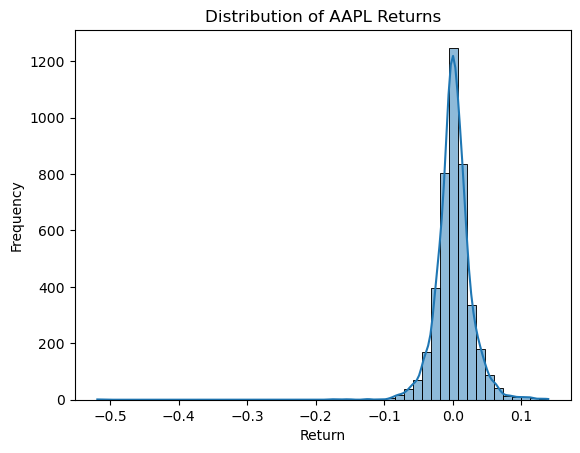

In [8]:
# get the distribution of the return
import matplotlib.pyplot as plt
import seaborn as sns   
sns.histplot(AAPLReturn.dropna(), bins=50, kde=True)
plt.title('Distribution of AAPL Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()

In [9]:
# there is a very long tail in the distribution, is this a error in data or not? Check it.
AAPLReturn[AAPLReturn < -0.3]


Dt
2000-09-29   -0.518677
Name: Adj Close, dtype: float64

Already check the news, this is the real market data.
So the AAPL stock data, is clean and no need for other proprocess

## Get the train/validation/train split
This time only for AAPL data itself

But before the split, some decision have to do
* The window of date for each training sample: I will first set it to 1 year. But I will set the function flexiable to adjust the window
* The data arrange: 0.15 for validation, 0.15 for training, and in order to get the max use of the data, so I will use a window just slide through to get the data

In [10]:
# get the data into three part: up, down and flat

x_train, y_train, x_val, y_val, x_test, y_test = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size = 252, add_transformed_features=0, target_mode="raw", return_index=False)

In [11]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape) 
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (2816, 252, 8)
y_train shape: (2816,)
x_val shape: (603, 252, 8)
y_val shape: (603,)
x_test shape: (605, 252, 8)
y_test shape: (605,)


### Exploratory Data Analysis

In [12]:
# using -0.01 as down threshold and 0.01 as up threshold, get the category of the return
y_train_cat = np.where(y_train < -0.01, 0, np.where(y_train > 0.01, 2, 1))
y_val_cat = np.where(y_val < -0.01, 0, np.where(y_val > 0.01, 2, 1))
y_test_cat = np.where(y_test < -0.01, 0, np.where(y_test > 0.01, 2, 1))   

# get the ratio of the three categories in the training set
unique, counts = np.unique(y_train_cat, return_counts=True)
category_counts = dict(zip(unique, counts))
print("Training set category distribution:")
for category, count in category_counts.items():
    print(f"Category {category}: {count} samples, {count/len(y_train_cat)*100:.2f}%")

unique, counts = np.unique(y_val_cat, return_counts=True)
category_counts = dict(zip(unique, counts))
print("Validation set category distribution:")
for category, count in category_counts.items():
    print(f"Category {category}: {count} samples, {count/len(y_val_cat)*100:.2f}%")

Training set category distribution:
Category 0: 810 samples, 28.76%
Category 1: 1061 samples, 37.68%
Category 2: 945 samples, 33.56%
Validation set category distribution:
Category 0: 127 samples, 21.06%
Category 1: 322 samples, 53.40%
Category 2: 154 samples, 25.54%


There is a change in the distribution, but this is kinda acceptable


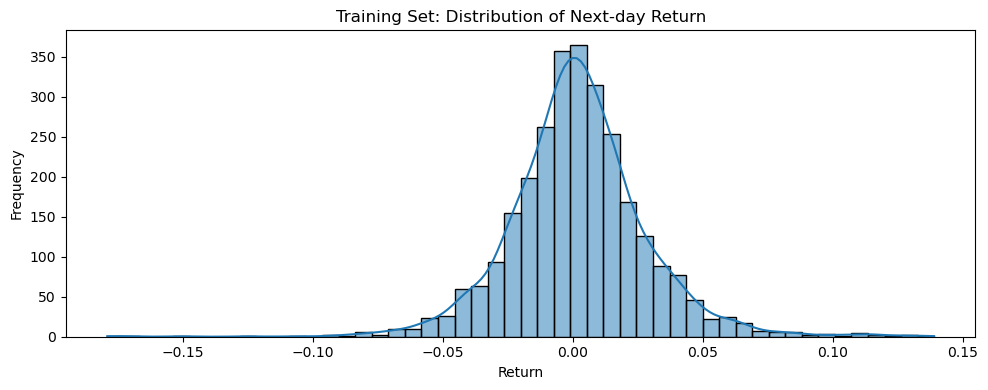

Top correlated last-day features with Return:
Volume       0.009736
Factor      -0.007064
Adj Close   -0.004444
Close       -0.003183
High        -0.002762
Open        -0.002670
Low         -0.002300
Div               NaN
dtype: float64


/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


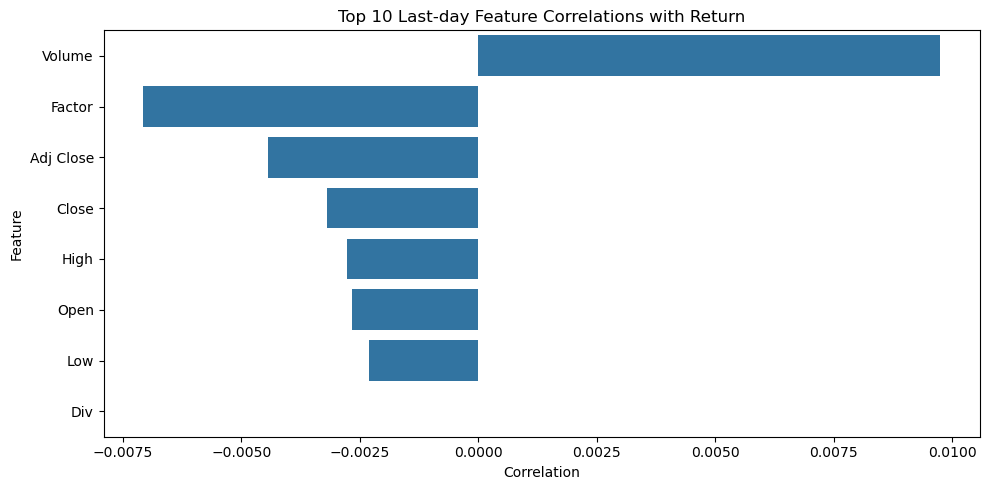

/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/ml_course/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top correlated window-summary features with Return:
Volume_min       -0.019784
Factor_mean       0.012703
Factor_max        0.012703
Factor_std        0.012703
Volume_mean      -0.010652
Adj Close_std    -0.007400
Adj Close_max    -0.004203
Volume_std        0.004007
Adj Close_mean   -0.003988
High_std          0.003846
dtype: float64


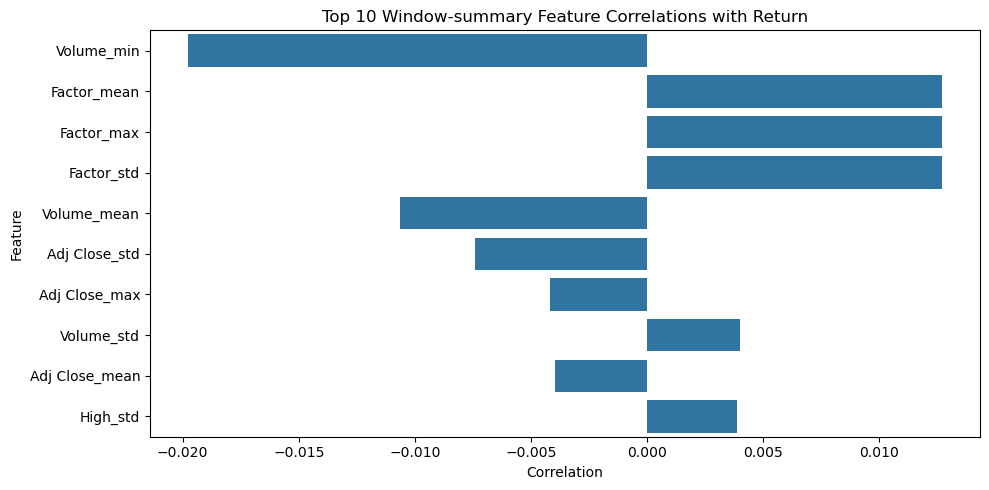

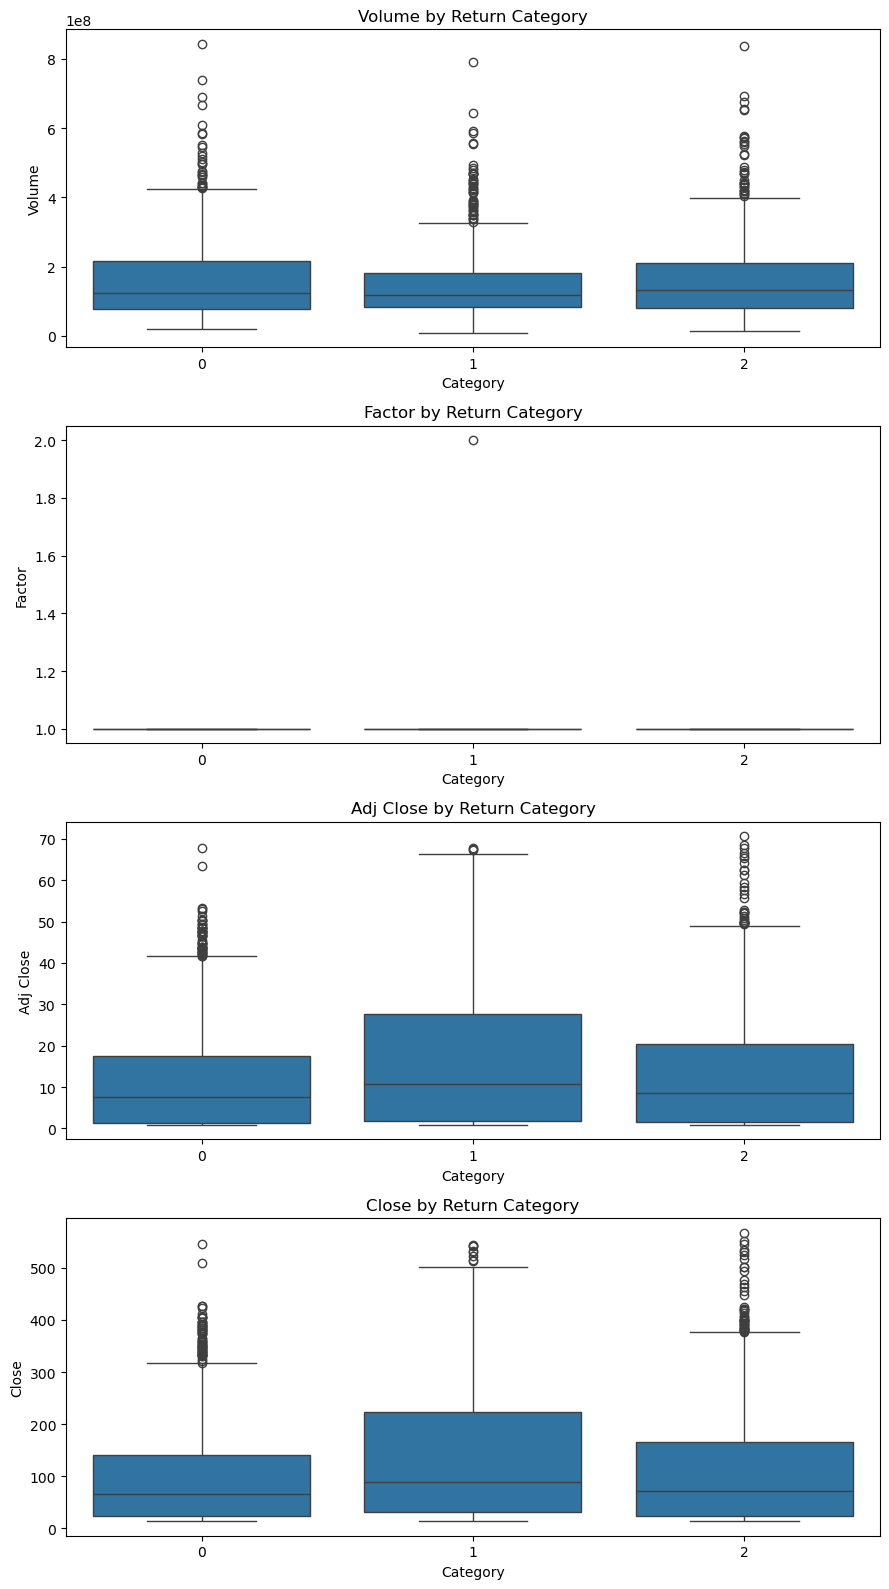

In [13]:
# EDA using train data only


# feature names: keep the same order as single_stock_split
feature_names = AAPL_data.columns.tolist()

# use only train set
X_last = pd.DataFrame(x_train[:, -1, :], columns=feature_names)
y = pd.Series(y_train, name="Return")

# 1) distribution of target in train set
plt.figure(figsize=(10, 4))
sns.histplot(y, bins=50, kde=True)
plt.title("Training Set: Distribution of Next-day Return")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) correlation of last-day features with target
corr_last = X_last.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top correlated last-day features with Return:")
print(corr_last.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_last.head(10).values, y=corr_last.head(10).index, orient="h")
plt.title("Top 10 Last-day Feature Correlations with Return")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 3) window-level summary features
X_mean = pd.DataFrame(x_train.mean(axis=1), columns=[f"{c}_mean" for c in feature_names])
X_std = pd.DataFrame(x_train.std(axis=1), columns=[f"{c}_std" for c in feature_names])
X_min = pd.DataFrame(x_train.min(axis=1), columns=[f"{c}_min" for c in feature_names])
X_max = pd.DataFrame(x_train.max(axis=1), columns=[f"{c}_max" for c in feature_names])

summary_df = pd.concat([X_mean, X_std, X_min, X_max], axis=1)
corr_summary = summary_df.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)

print("Top correlated window-summary features with Return:")
print(corr_summary.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_summary.head(10).values, y=corr_summary.head(10).index, orient="h")
plt.title("Top 10 Window-summary Feature Correlations with Return")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 4) compare feature behavior for up / down / flat
top_feats = corr_last.head(4).index.tolist()
fig, axes = plt.subplots(len(top_feats), 1, figsize=(9, 4 * len(top_feats)))
if len(top_feats) == 1:
    axes = [axes]

for ax, col in zip(axes, top_feats):
    sns.boxplot(x=y_train_cat, y=X_last[col], ax=ax)
    ax.set_title(f"{col} by Return Category")
    ax.set_xlabel("Category")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

For the original data, it barely shows any prediction power.
First we see the if there is some magic from this orignal data's deep learning model. Get some baseline.
Then, we try: transfer of the data maybe helpful? Get some more transformation for data


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0946 - macro_f1: 0.3621 - val_loss: 1.0752 - val_macro_f1: 0.2911
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0802 - macro_f1: 0.3705 - val_loss: 1.0522 - val_macro_f1: 0.2876
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0834 - macro_f1: 0.3500 - val_loss: 1.0278 - val_macro_f1: 0.2883
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0763 - macro_f1: 0.3780 - val_loss: 1.0333 - val_macro_f1: 0.2883
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0735 - macro_f1: 0.3940 - val_loss: 1.0537 - val_macro_f1: 0.2961
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0967 - macro_f1: 0.3625 - val_loss: 1.0408 - val_macro_f1: 0.2714
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0899 - macro_f1: 0.3690 - val_loss: 1.0244 - val_macro_f1: 0.2622
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0849 - macro_f1: 0.3394 - val_loss: 1.0302 - val_macro_

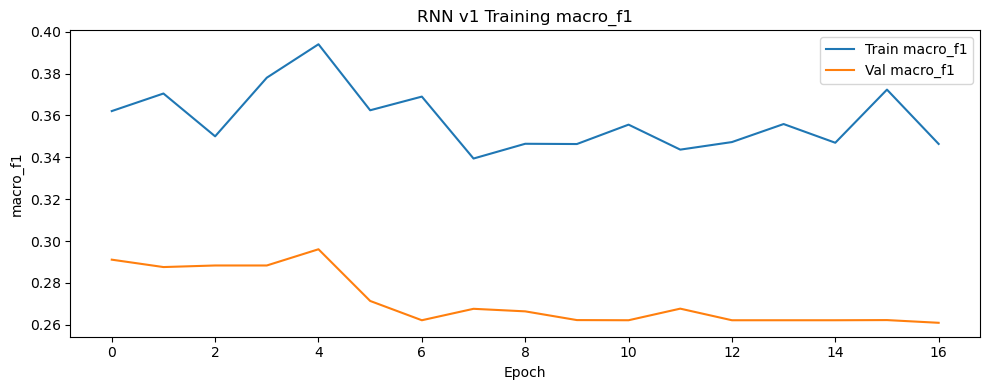

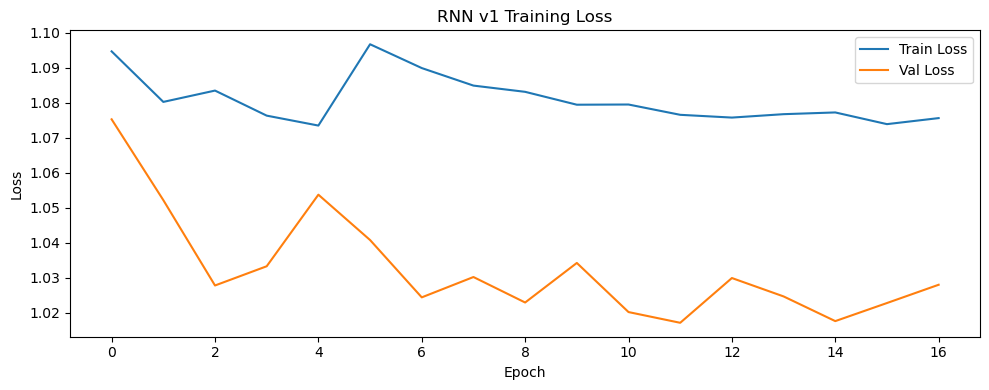

In [14]:
# RNN baseline for the 3-class direction task
# labels are already in {0, 1, 2} from split
x_train, y_train, x_val, y_val, x_test, y_test = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size = 252, add_transformed_features=0, target_mode="direction_3class", return_index=False)
y_train_rnn = y_train
y_val_rnn = y_val
y_test_rnn = y_test

# Scale each feature using statistics from the training set only
train_mean = x_train.mean(axis=(0, 1), keepdims=True)
train_std = x_train.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn = (x_train - train_mean) / train_std
x_val_rnn = (x_val - train_mean) / train_std
x_test_rnn = (x_test - train_mean) / train_std

num_classes = 3
input_shape = x_train_rnn.shape[1:]

keras.backend.clear_session()

rnn_model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.1),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes)],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = rnn_model.fit(
    x_train_rnn,
    y_train_rnn,
    validation_data=(x_val_rnn, y_val_rnn),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

# direct validation evaluation helper
rnn_results = evaluate_keras_model_on_validation(
    model=rnn_model,
    history=history,
    x_val=x_val_rnn,
    y_val_cat=y_val_rnn,
    prefix="v1",
)


Based on the F1 and confusion matrix, the biggest problem right now is model just try to predict most of the result to be flat, rather than guess whether there is a up or down. So the next improvement I would like to do is to design a loss function really meet my requirement. Not just give a flat pridict, but make prediction on up or down.

My idea of improvement of loss function:
* Punish model a little bit when making flat prediction.
* No punish if the result is flating while predicting up or down
* Severily punish the model is make down prediction when down or make up prediction when up


Epoch 1/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 2.5667 - macro_f1: 0.2746 - val_loss: 2.2569 - val_macro_f1: 0.1574 - learning_rate: 7.0000e-04
Epoch 2/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 2.5444 - macro_f1: 0.2695 - val_loss: 2.3378 - val_macro_f1: 0.1501 - learning_rate: 7.0000e-04
Epoch 3/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 2.5340 - macro_f1: 0.2558 - val_loss: 2.2542 - val_macro_f1: 0.2934 - learning_rate: 7.0000e-04
Epoch 4/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 2.5308 - macro_f1: 0.2702 - val_loss: 2.2549 - val_macro_f1: 0.1574 - learning_rate: 7.0000e-04
Epoch 5/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 2.5323 - macro_f1: 0.2811 - val_loss: 2.2469 - val_macro_f1: 0.1551 - learning_rate: 7.0000e-04
Epoch 6/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 2.5398 - macro_f1: 0.2501 - val_loss: 2.2575 - val_macro_f1: 0.1568 - learning_rate: 7.0000e-04
Epoch 7/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 2.5374 - ma

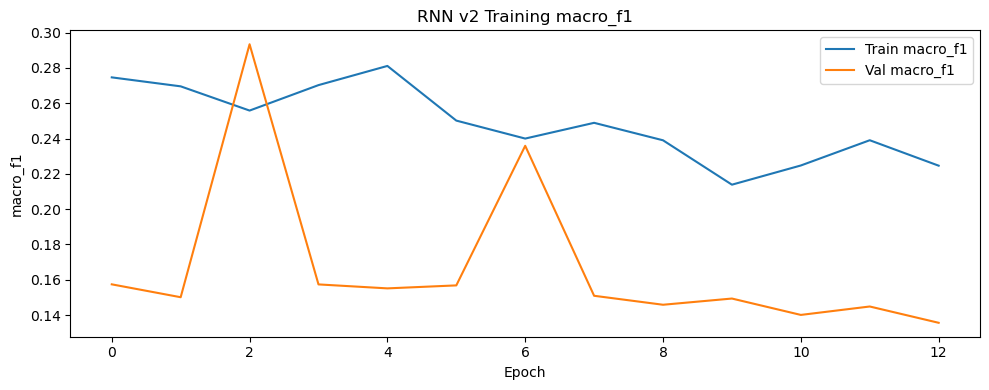

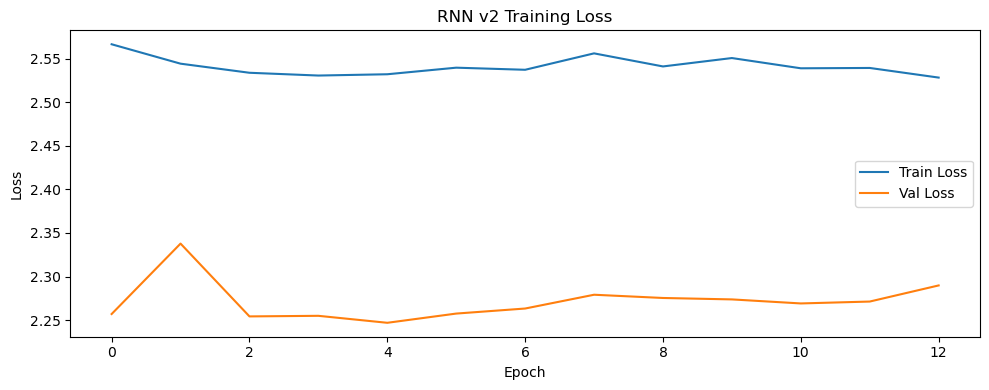

In [15]:
# New model (appended): deeper RNN with custom cost-sensitive loss

# labels are already in {0, 1, 2} from split
y_train_rnn_v2 = y_train
y_val_rnn_v2 = y_val

# train-only normalization
train_mean_v2 = x_train.mean(axis=(0, 1), keepdims=True)
train_std_v2 = x_train.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v2 = (x_train - train_mean_v2) / train_std_v2
x_val_rnn_v2 = (x_val - train_mean_v2) / train_std_v2

num_classes_v2 = 3
input_shape_v2 = x_train_rnn_v2.shape[1:]

keras.backend.clear_session()

rnn_model_v2 = keras.Sequential([
    layers.Input(shape=input_shape_v2),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v2, activation="softmax"),
])

# Custom cost matrix: rows=true [Down, Flat, Up], cols=pred [Down, Flat, Up]
loss_matrix_v2 = np.array([
    [0.0, 3.0, 3.0],
    [0.0, 0.2, 0.0],
    [3.0, 3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v2 = tf.constant(loss_matrix_v2, dtype=tf.float32)

def matrix_weighted_loss_v2(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v2)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v2)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v2 = 1.2
    return ce + lambda_cost_v2 * expected_cost

rnn_model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v2,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v2)],
)

callbacks_v2 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v2 = rnn_model_v2.fit(
    x_train_rnn_v2,
    y_train_rnn_v2,
    validation_data=(x_val_rnn_v2, y_val_rnn_v2),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v2,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v2 = evaluate_keras_model_on_validation(
    model=rnn_model_v2,
    history=history_v2,
    x_val=x_val_rnn_v2,
    y_val_cat=y_val_rnn_v2,
    prefix="v2",
)


To adjust for the loss function may be a good idea, but after trying different loss matrix, the biggest problem right now for the model is there is nothing for it to learn. 
Even after changing the loss matrix to stop the model to all predict flat, it then change to strategy that predicting everything in Up.

### Transform of data and expand the data

In [16]:
# make the transformation of the data
# what is the potential informatiion within the data?

# some ideas:
# Returns
# Moving averages of return(e.g., 5-day, 20-day, 50-day)
# MACD  (one EMA minus another EMA)
# Volatility measures (e.g., rolling standard deviation of returns)
# Bolling bands (moving average plus/minus a multiple of rolling std)
# Relative Strength Index (RSI)
# SAR
# strat_cci 
# strat_arbr 
# pvi
# volume z-score
# return sign / streak

# here lets see the results of adding some of these features to the RNN model, and see if it can improve the performance
x_train_ext, y_train_ext, x_val_ext, y_val_ext, x_test_ext, y_test_ext = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=1, target_mode="direction_3class", return_index=False)

print("x_train_ext shape:", x_train_ext.shape)
print("y_train_ext shape:", y_train_ext.shape)
print("x_val_ext shape:", x_val_ext.shape) 
print("y_val_ext shape:", y_val_ext.shape)
print("x_test_ext shape:", x_test_ext.shape)
print("y_test_ext shape:", y_test_ext.shape)


x_train_ext shape: (2782, 252, 29)
y_train_ext shape: (2782,)
x_val_ext shape: (596, 252, 29)
y_val_ext shape: (596,)
x_test_ext shape: (597, 252, 29)
y_test_ext shape: (597,)


Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 2.5945 - macro_f1: 0.3145 - val_loss: 2.2798 - val_macro_f1: 0.2936 - learning_rate: 7.0000e-04
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.5071 - macro_f1: 0.3163 - val_loss: 2.2606 - val_macro_f1: 0.2672 - learning_rate: 7.0000e-04
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4941 - macro_f1: 0.2922 - val_loss: 2.2550 - val_macro_f1: 0.3650 - learning_rate: 7.0000e-04
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4711 - macro_f1: 0.3259 - val_loss: 2.2649 - val_macro_f1: 0.2485 - learning_rate: 7.0000e-04
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4715 - macro_f1: 0.3210 - val_loss: 2.2466 - val_macro_f1: 0.1803 - learning_rate: 7.0000e-04
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 2.4446 - macro_f1: 0.3284 - val_loss: 2.2659 - val_macro_f1: 0.3040 - learning_rate: 7.0000e-04
Epoch 7/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4324 - ma

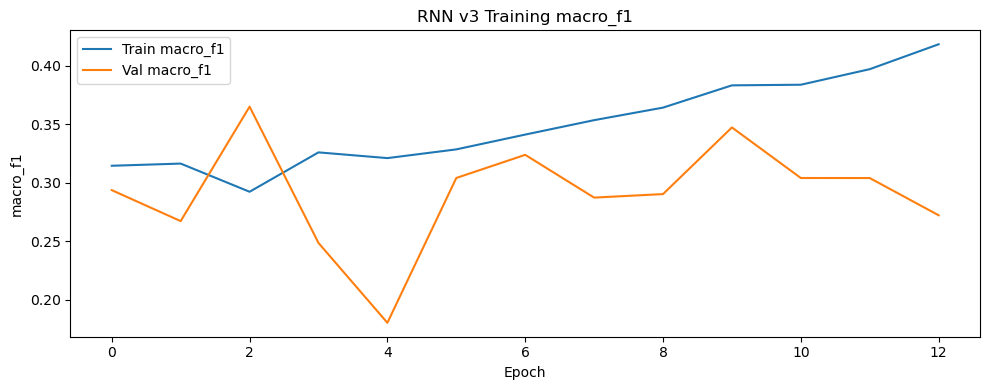

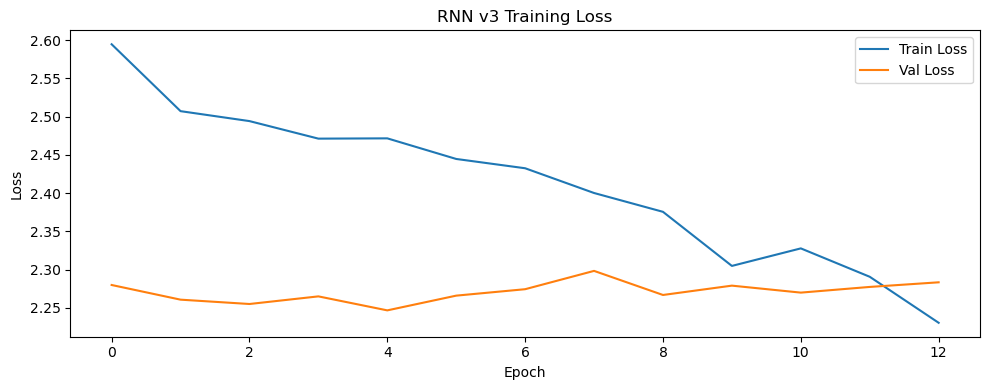

In [17]:
# v3: same setup as v2, but trained on extended features (x_*_ext)

# labels are already in {0, 1, 2} from split
y_train_rnn_v3 = y_train_ext
y_val_rnn_v3 = y_val_ext

# train-only normalization
train_mean_v3 = x_train_ext.mean(axis=(0, 1), keepdims=True)
train_std_v3 = x_train_ext.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v3 = (x_train_ext - train_mean_v3) / train_std_v3
x_val_rnn_v3 = (x_val_ext - train_mean_v3) / train_std_v3

num_classes_v3 = 3
input_shape_v3 = x_train_rnn_v3.shape[1:]

keras.backend.clear_session()

rnn_model_v3 = keras.Sequential([
    layers.Input(shape=input_shape_v3),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v3, activation="softmax"),
])

# Same cost matrix and weighted loss as v2
loss_matrix_v3 = np.array([
    [0.0, 3.0, 3.0],
    [0.0, 0.2, 0.0],
    [3.0, 3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v3 = tf.constant(loss_matrix_v3, dtype=tf.float32)

def matrix_weighted_loss_v3(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v3)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v3)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v3 = 1.2
    return ce + lambda_cost_v3 * expected_cost

rnn_model_v3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v3,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v3)],
)

callbacks_v3 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v3 = rnn_model_v3.fit(
    x_train_rnn_v3,
    y_train_rnn_v3,
    validation_data=(x_val_rnn_v3, y_val_rnn_v3),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v3,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v3 = evaluate_keras_model_on_validation(
    model=rnn_model_v3,
    history=history_v3,
    x_val=x_val_rnn_v3,
    y_val_cat=y_val_rnn_v3,
    prefix="v3",
)


I mean, at least the model start to make some judgement, which means that this may really helpful. Though the this model still try to guess everything as up, at lease make some try already.

x_train_ext shape: (2782, 252, 29)
y_train_ext shape: (2782,)
x_val_ext shape: (596, 252, 29)
y_val_ext shape: (596,)
x_test_ext shape: (597, 252, 29)
y_test_ext shape: (597,)
Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 2.5466 - macro_f1: 0.2784 - val_loss: 2.2454 - val_macro_f1: 0.3868 - learning_rate: 7.0000e-04
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.5099 - macro_f1: 0.3066 - val_loss: 2.2336 - val_macro_f1: 0.3487 - learning_rate: 7.0000e-04
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4643 - macro_f1: 0.3238 - val_loss: 2.2479 - val_macro_f1: 0.3327 - learning_rate: 7.0000e-04
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4782 - macro_f1: 0.3279 - val_loss: 2.2557 - val_macro_f1: 0.2732 - learning_rate: 7.0000e-04
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4520 - macro_f1: 0.3187 - val_loss: 2.2492 - val_macro_f1: 0.3457 - learning_rate: 7.0000e-04
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/ste

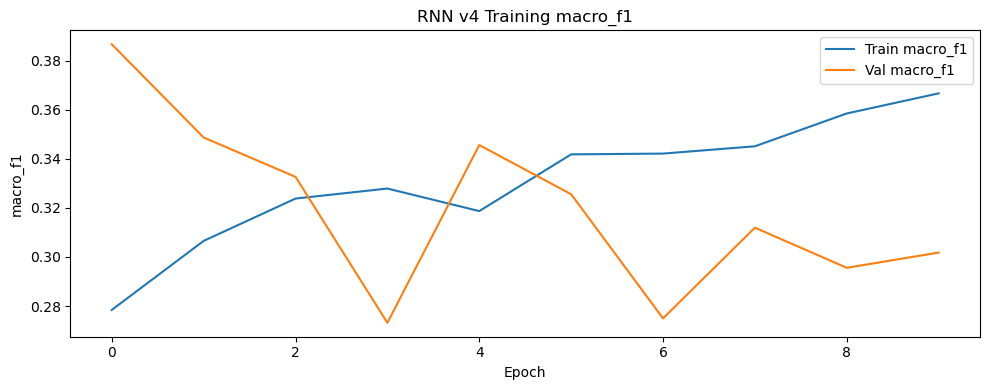

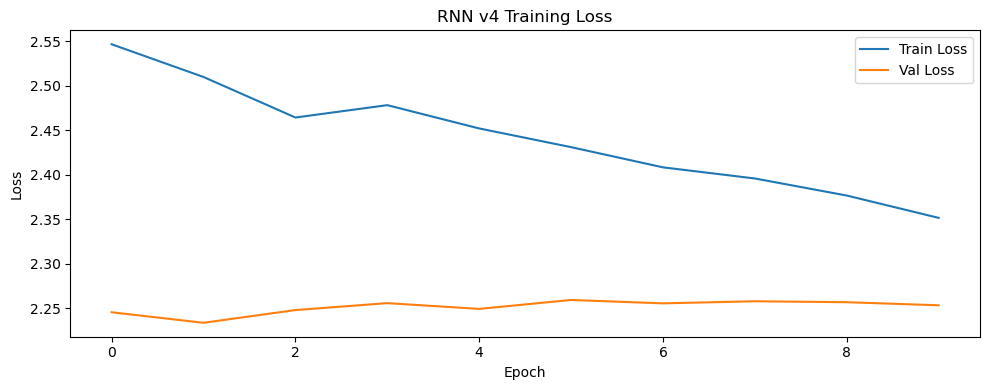

In [18]:
# Only keep the original OHLCV features (no extended features) but use the same model architecture and training setup as v3, to see if the improvement in v3 is from the model/training or from the features.
x_train_ext, y_train_ext, x_val_ext, y_val_ext, x_test_ext, y_test_ext = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=2, target_mode="direction_3class", return_index=False)

print("x_train_ext shape:", x_train_ext.shape)
print("y_train_ext shape:", y_train_ext.shape)
print("x_val_ext shape:", x_val_ext.shape) 
print("y_val_ext shape:", y_val_ext.shape)
print("x_test_ext shape:", x_test_ext.shape)
print("y_test_ext shape:", y_test_ext.shape)

# labels are already in {0, 1, 2} from split
y_train_rnn_v4 = y_train_ext
y_val_rnn_v4 = y_val_ext

# train-only normalization
train_mean_v4 = x_train_ext.mean(axis=(0, 1), keepdims=True)
train_std_v4 = x_train_ext.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v4 = (x_train_ext - train_mean_v4) / train_std_v4
x_val_rnn_v4 = (x_val_ext - train_mean_v4) / train_std_v4

num_classes_v4 = 3
input_shape_v4 = x_train_rnn_v4.shape[1:]

keras.backend.clear_session()

rnn_model_v4 = keras.Sequential([
    layers.Input(shape=input_shape_v4),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v4, activation="softmax"),
])

# Same cost matrix and weighted loss as v2
loss_matrix_v4 = np.array([
    [0.0, 3.0, 3.0],
    [0.0, 0.2, 0.0],
    [3.0, 3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v4 = tf.constant(loss_matrix_v4, dtype=tf.float32)

def matrix_weighted_loss_v4(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v4)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v4)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v4 = 1.2
    return ce + lambda_cost_v4 * expected_cost

rnn_model_v4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v4,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v4)],
)

callbacks_v4 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v4 = rnn_model_v4.fit(
    x_train_rnn_v4,
    y_train_rnn_v4,
    validation_data=(x_val_rnn_v4, y_val_rnn_v4),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v4,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v4 = evaluate_keras_model_on_validation(
    model=rnn_model_v4,
    history=history_v4,
    x_val=x_val_rnn_v4,
    y_val_cat=y_val_rnn_v4,
    prefix="v4",
)


Almost no improvement, just struggle.

In [19]:
from functools import reduce

# Now lets adding for information inside, let the model sturggele in higher demension ;)

# naive process, directly adding all feature in other stock

# Read all other stock files and merge them into one wide table on Dt
other_stock_paths = sorted((DATA_DIR).glob('*.csv'))
other_stock_paths = [p for p in other_stock_paths if p.stem != 'AAPL']

other_stock_tables = []
for stock_path in other_stock_paths:
    stock_name = stock_path.stem
    stock_df = pd.read_csv(stock_path)
    stock_df['Dt'] = pd.to_datetime(stock_df['Dt'])
    stock_df = stock_df.sort_values('Dt').drop_duplicates(subset='Dt')
    stock_df = stock_df.rename(columns={col: f'{stock_name}_{col}' for col in stock_df.columns if col != 'Dt'})
    other_stock_tables.append(stock_df)

other_stocks_big_table = reduce(lambda left, right: pd.merge(left, right, on='Dt', how='inner'), other_stock_tables)
other_stocks_big_table.set_index('Dt', inplace=True)

print('other_stocks_big_table shape:', other_stocks_big_table.shape)
other_stocks_big_table.head()

other_stocks_big_table shape: (4277, 184)


,ACN_Adj Close,ACN_Close,ACN_Div,ACN_Factor,ACN_High,ACN_Low,ACN_Open,ACN_Volume,ADBE_Adj Close,ADBE_Close,...,XLV_Open,XLV_Volume,XLY_Adj Close,XLY_Close,XLY_Div,XLY_Factor,XLY_High,XLY_Low,XLY_Open,XLY_Volume
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2747,65.563,...,31.000,246700.0,23.6030,30.125,0.0,1.0,31.0000,29.8590,31.000,212900.0
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.9094,60.063,...,30.188,35300.0,22.8930,29.219,0.0,1.0,29.8130,29.0310,29.688,177200.0
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.2042,61.250,...,29.781,137600.0,22.6114,28.859,0.0,1.0,29.3461,28.7190,29.344,124600.0
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.3283,61.750,...,29.313,50000.0,22.8685,29.188,0.0,1.0,29.4060,28.9991,29.047,135800.0
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0730,64.750,...,29.469,22100.0,23.9458,30.563,0.0,1.0,30.5630,29.5000,29.500,70000.0


In [20]:
# get this big table into the same format as x_train, x_val, x_test, and then we can concatenate it with the original features for AAPL to train the model
x_train, y_train, x_val, y_val, x_test, y_test = multi_stock_split(AAPL_data, AAPLReturn, other_stocks_big_table,train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=1, target_mode="direction_3class", return_index=False)
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape) 
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (41, 252, 213)
y_train shape: (41,)
x_val shape: (8, 252, 213)
y_val shape: (8,)
x_test shape: (10, 252, 213)
y_test shape: (10,)


In [21]:

# I can't directly use the merged data, as the missing data in the other stock will cause the number of samples to drop significantly, so I need to do some imputation for the missing data, and then train the model on the imputed data.
# So I have to check the the missing data first

start_dates = []

stock_names = sorted({col.split('_', 1)[0] for col in other_stocks_big_table.columns if '_' in col})

for stock in stock_names:
    stock_cols = [c for c in other_stocks_big_table.columns if c.startswith(f"{stock}_")]
    has_data = other_stocks_big_table[stock_cols].notna().any(axis=1)
    first_date = has_data[has_data].index.min() if has_data.any() else pd.NaT
    start_dates.append((stock, first_date, len(stock_cols)))

start_dates_df = pd.DataFrame(start_dates, columns=["Stock", "FirstAvailableDate", "NumFeatures"]).sort_values("FirstAvailableDate")
print(start_dates_df.to_string(index=False))

Stock FirstAvailableDate  NumFeatures
  SPY         2000-01-03            8
  XLU         2000-01-03            8
  XLP         2000-01-03            8
  XLK         2000-01-03            8
  XLI         2000-01-03            8
  XLF         2000-01-03            8
  XLE         2000-01-03            8
  XLB         2000-01-03            8
  XLV         2000-01-03            8
 NVDA         2000-01-03            8
  XLY         2000-01-03            8
 INTC         2000-01-03            8
  IBM         2000-01-03            8
 CSCO         2000-01-03            8
 ADBE         2000-01-03            8
 MSFT         2000-01-03            8
  ACN         2001-07-19            8
  CRM         2004-06-23            8
 GOOG         2004-08-19            8
   MA         2006-05-25            8
    V         2008-03-19            8
   FB         2012-05-18            8
 XLRE         2015-10-08            8


In [22]:
# so as long as I delete  MA/V/FB/XLRE then the time is fine
deleted_stocks = {'MA', 'V', 'FB', 'XLRE'}

# only drop columns whose stock prefix is exactly in deleted_stocks
cols_to_drop = [
    col for col in other_stocks_big_table.columns
    if col.split('_', 1)[0] in deleted_stocks
]

other_stocks_big_table_dropped = other_stocks_big_table.drop(columns=cols_to_drop)

print("dropped columns:", len(cols_to_drop))
print("other_stocks_big_table_dropped shape:", other_stocks_big_table_dropped.shape)
other_stocks_big_table_dropped.head()

dropped columns: 32
other_stocks_big_table_dropped shape: (4277, 152)


,ACN_Adj Close,ACN_Close,ACN_Div,ACN_Factor,ACN_High,ACN_Low,ACN_Open,ACN_Volume,ADBE_Adj Close,ADBE_Close,...,XLV_Open,XLV_Volume,XLY_Adj Close,XLY_Close,XLY_Div,XLY_Factor,XLY_High,XLY_Low,XLY_Open,XLY_Volume
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2747,65.563,...,31.000,246700.0,23.6030,30.125,0.0,1.0,31.0000,29.8590,31.000,212900.0
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.9094,60.063,...,30.188,35300.0,22.8930,29.219,0.0,1.0,29.8130,29.0310,29.688,177200.0
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.2042,61.250,...,29.781,137600.0,22.6114,28.859,0.0,1.0,29.3461,28.7190,29.344,124600.0
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.3283,61.750,...,29.313,50000.0,22.8685,29.188,0.0,1.0,29.4060,28.9991,29.047,135800.0
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0730,64.750,...,29.469,22100.0,23.9458,30.563,0.0,1.0,30.5630,29.5000,29.500,70000.0


In [23]:
x_train, y_train, x_val, y_val, x_test, y_test = multi_stock_split(AAPL_data, AAPLReturn, other_stocks_big_table_dropped,train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=1, target_mode="direction_3class", return_index=False)
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape) 
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (2004, 252, 181)
y_train shape: (2004,)
x_val shape: (429, 252, 181)
y_val shape: (429,)
x_test shape: (430, 252, 181)
y_test shape: (430,)


Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 2.4912 - macro_f1: 0.2734 - val_loss: 2.1515 - val_macro_f1: 0.2135 - learning_rate: 7.0000e-04
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 2.4321 - macro_f1: 0.2966 - val_loss: 2.2298 - val_macro_f1: 0.1508 - learning_rate: 7.0000e-04
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 2.4171 - macro_f1: 0.3387 - val_loss: 2.1714 - val_macro_f1: 0.2137 - learning_rate: 7.0000e-04
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 2.4009 - macro_f1: 0.3147 - val_loss: 2.1777 - val_macro_f1: 0.1341 - learning_rate: 7.0000e-04
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 2.3688 - macro_f1: 0.3373 - val_loss: 2.1757 - val_macro_f1: 0.1509 - learning_rate: 3.5000e-04
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 2.3559 - macro_f1: 0.3345 - val_loss: 2.1868 - val_macro_f1: 0.1472 - learning_rate: 3.5000e-04
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 2.3350 - ma

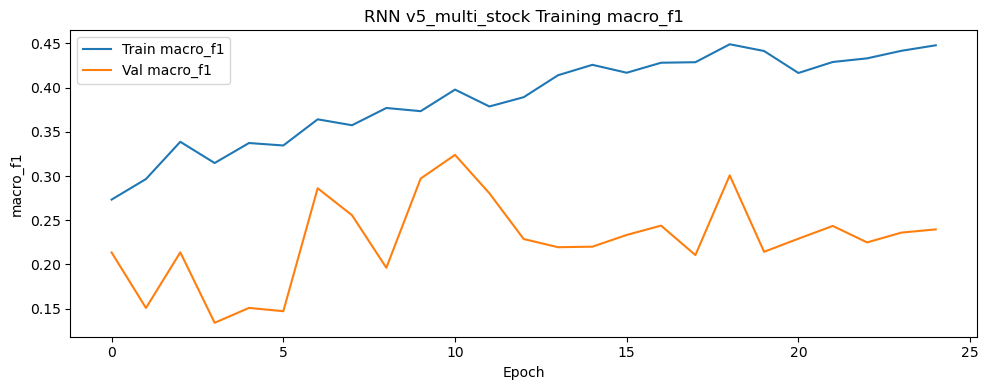

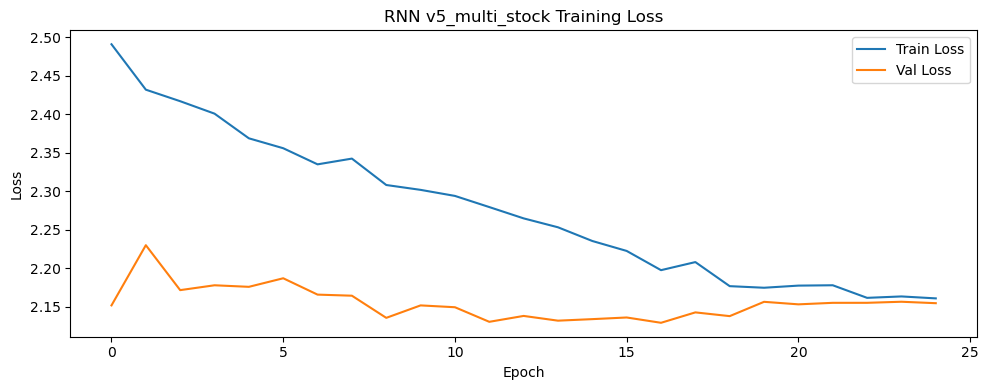

In [24]:
# now still use RNN but see with more feature inside if there is magic

# v5: RNN on multi-stock features (same setup style as v3/v4)

# labels already in {0,1,2}
y_train_rnn_v5 = y_train
y_val_rnn_v5 = y_val
y_test_rnn_v5 = y_test

# train-only normalization
train_mean_v5 = x_train.mean(axis=(0, 1), keepdims=True)
train_std_v5 = x_train.std(axis=(0, 1), keepdims=True) + 1e-8

x_train_rnn_v5 = (x_train - train_mean_v5) / train_std_v5
x_val_rnn_v5 = (x_val - train_mean_v5) / train_std_v5
x_test_rnn_v5 = (x_test - train_mean_v5) / train_std_v5

num_classes_v5 = 3
input_shape_v5 = x_train_rnn_v5.shape[1:]

keras.backend.clear_session()

rnn_model_v5 = keras.Sequential([
    layers.Input(shape=input_shape_v5),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v5, activation="softmax"),
])

# same cost-sensitive loss as before
loss_matrix_v5 = np.array([
    [0.0, 3.0, 3.0],  # true Down
    [0.0, 0.2, 0.0],  # true Flat
    [3.0, 3.0, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v5 = tf.constant(loss_matrix_v5, dtype=tf.float32)

def matrix_weighted_loss_v5(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v5)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v5)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v5 = 1.2
    return ce + lambda_cost_v5 * expected_cost

rnn_model_v5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v5,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v5)],
)

callbacks_v5 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v5 = rnn_model_v5.fit(
    x_train_rnn_v5,
    y_train_rnn_v5,
    validation_data=(x_val_rnn_v5, y_val_rnn_v5),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v5,
    verbose=1,
)

# validation evaluation
rnn_results_v5 = evaluate_keras_model_on_validation(
    model=rnn_model_v5,
    history=history_v5,
    x_val=x_val_rnn_v5,
    y_val_cat=y_val_rnn_v5,
    prefix="v5_multi_stock",
)


No magic...
So at least tell us if we don't transfer the origin model then it barely learns
Other possible helping solution:
1. Start transfer the original data of other stocks <-- try this first
2. Change model


In [12]:
# since we want to transfer the data, we need to understand the data.
# the indicator of the market: SPY
# start from add_technical_features output, then append alpha/beta from ret_1d.

AAPL_data_expand = add_technical_features(AAPL_data)
AAPL_data_expand.head(20)

,Adj Close,Close,Div,Factor,High,Low,Open,Volume,ret_1d,ret_ma_5,...,bb_width,rsi_14,sar,cci_20,strat_ar,strat_br,volume_z_20,pvi,ret_sign,ret_streak
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,3.4785,111.938,0.0,1.0,112.5000,101.6880,104.8750,133949200.0,NaN,NaN,...,NaN,NaN,101.688000,NaN,NaN,NaN,NaN,1000.000000,NaN,0.0
2000-01-04,3.1852,102.500,0.0,1.0,110.6250,101.1880,108.2500,128094400.0,-0.084318,NaN,...,NaN,NaN,112.500000,NaN,NaN,NaN,NaN,1000.000000,-1.0,-1.0
2000-01-05,3.2318,104.000,0.0,1.0,110.5630,103.0000,103.7500,194580400.0,0.014630,NaN,...,NaN,NaN,112.500000,NaN,NaN,NaN,NaN,1014.630165,1.0,1.0
2000-01-06,2.9521,95.000,0.0,1.0,107.0000,95.0000,106.1183,191993200.0,-0.086546,NaN,...,NaN,NaN,112.273760,NaN,NaN,NaN,NaN,1014.630165,-1.0,-1.0
2000-01-07,3.0920,99.500,0.0,1.0,101.0000,95.5000,96.5000,115183600.0,0.047390,NaN,...,NaN,NaN,111.582810,NaN,NaN,NaN,NaN,1014.630165,1.0,1.0
2000-01-10,3.0376,97.750,0.0,1.0,102.2500,94.7500,102.0000,126266000.0,-0.017594,-0.025288,...,NaN,NaN,110.919497,NaN,NaN,NaN,NaN,996.778974,-1.0,-1.0
2000-01-11,2.8822,92.750,0.0,1.0,99.3750,90.5000,95.9380,110387200.0,-0.051159,-0.018656,...,NaN,NaN,109.949327,NaN,NaN,NaN,NaN,996.778974,-1.0,-2.0
2000-01-12,2.7094,87.188,0.0,1.0,95.5012,86.5000,95.0000,244017200.0,-0.059954,-0.033573,...,NaN,NaN,108.393381,NaN,NaN,NaN,NaN,937.017886,-1.0,-3.0
2000-01-13,3.0065,96.750,0.0,1.0,98.7500,92.5000,94.4840,258171200.0,0.109655,0.005668,...,NaN,NaN,106.204043,NaN,NaN,NaN,NaN,1039.766840,1.0,1.0


In [13]:
# Keep rolling alpha/beta, then merge SPY features and add excess-return features.
AAPL_data_expand = add_rolling_alpha_beta_from_ret1d(
    stock_features_df=AAPL_data_expand,
    market_data=DATA_DIR / "SPY.csv",
    rolling_window=30,
)

AAPL_data_expand = add_rolling_alpha_beta_from_ret1d(
    stock_features_df=AAPL_data_expand,
    market_data=DATA_DIR / "SPY.csv",
    rolling_window=60,
)
AAPL_data_expand['alpha_60minus_30'] = AAPL_data_expand['alpha_60'] - AAPL_data_expand['alpha_30']
AAPL_data_expand['beta_60minus_30'] = AAPL_data_expand['beta_60'] - AAPL_data_expand['beta_30']

SPY_raw = pd.read_csv(DATA_DIR / "SPY.csv")
SPY_raw["Dt"] = pd.to_datetime(SPY_raw["Dt"], format="%Y-%m-%d", errors="coerce")
SPY_raw = SPY_raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")

spy_features = build_market_features(SPY_raw)

# Merge selected SPY features by date.
AAPL_data_expand = AAPL_data_expand.join(spy_features, how="left")

# Excess-return style features (AAPL minus SPY).
AAPL_data_expand["aapl_excess_ret_1d"] = AAPL_data_expand["ret_1d"] - AAPL_data_expand["spy_ret_1d"]
AAPL_data_expand["aapl_excess_ret_ma_5"] = AAPL_data_expand["ret_ma_5"] - AAPL_data_expand["spy_ret_ma_5"]
AAPL_data_expand["aapl_excess_ret_ma_20"] = AAPL_data_expand["ret_ma_20"] - AAPL_data_expand["spy_ret_ma_20"]

AAPL_data_expand.head(50)

,Adj Close,Close,Div,Factor,High,Low,Open,Volume,ret_1d,ret_ma_5,...,spy_macd_signal,spy_macd_hist,spy_bb_width,spy_rsi_14,spy_volume_z_20,spy_ret_sign,spy_ret_streak,aapl_excess_ret_1d,aapl_excess_ret_ma_5,aapl_excess_ret_ma_20
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,3.4785,111.938,0.0,1.0,112.5000,101.6880,104.8750,133949200.0,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2000-01-04,3.1852,102.500,0.0,1.0,110.6250,101.1880,108.2500,128094400.0,-0.084318,NaN,...,-0.062685,-0.250740,NaN,NaN,NaN,-1.0,-1.0,-0.045212,NaN,NaN
2000-01-05,3.2318,104.000,0.0,1.0,110.5630,103.0000,103.7500,194580400.0,0.014630,NaN,...,-0.158475,-0.383161,NaN,NaN,NaN,1.0,1.0,0.012841,NaN,NaN
2000-01-06,2.9521,95.000,0.0,1.0,107.0000,95.0000,106.1183,191993200.0,-0.086546,NaN,...,-0.294431,-0.543822,NaN,NaN,NaN,-1.0,-1.0,-0.070475,NaN,NaN
2000-01-07,3.0920,99.500,0.0,1.0,101.0000,95.5000,96.5000,115183600.0,0.047390,NaN,...,-0.359591,-0.260640,NaN,NaN,NaN,1.0,1.0,-0.010686,NaN,NaN
2000-01-10,3.0376,97.750,0.0,1.0,102.2500,94.7500,102.0000,126266000.0,-0.017594,-0.025288,...,-0.370631,-0.044163,NaN,NaN,NaN,1.0,2.0,-0.021024,-0.026911,NaN
2000-01-11,2.8822,92.750,0.0,1.0,99.3750,90.5000,95.9380,110387200.0,-0.051159,-0.018656,...,-0.365615,0.020065,NaN,NaN,NaN,-1.0,-1.0,-0.039193,-0.025707,NaN
2000-01-12,2.7094,87.188,0.0,1.0,95.5012,86.5000,95.0000,244017200.0,-0.059954,-0.033573,...,-0.365808,-0.000773,NaN,NaN,NaN,-1.0,-2.0,-0.050006,-0.038277,NaN
2000-01-13,3.0065,96.750,0.0,1.0,98.7500,92.5000,94.4840,258171200.0,0.109655,0.005668,...,-0.347068,0.074961,NaN,NaN,NaN,1.0,1.0,0.096112,-0.004959,NaN


x_train_exp shape: (2774, 252, 51)
y_train_exp shape: (2774,)
x_val_exp shape: (594, 252, 51)
y_val_exp shape: (594,)
x_test_exp shape: (596, 252, 51)
y_test_exp shape: (596,)
Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 2.5591 - macro_f1: 0.2685 - val_loss: 2.2507 - val_macro_f1: 0.2688 - learning_rate: 7.0000e-04
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.5027 - macro_f1: 0.3071 - val_loss: 2.2725 - val_macro_f1: 0.1803 - learning_rate: 7.0000e-04
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4620 - macro_f1: 0.3285 - val_loss: 2.2427 - val_macro_f1: 0.2561 - learning_rate: 7.0000e-04
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4498 - macro_f1: 0.3282 - val_loss: 2.2854 - val_macro_f1: 0.2545 - learning_rate: 7.0000e-04
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4594 - macro_f1: 0.3098 - val_loss: 2.2828 - val_macro_f1: 0.2973 - learning_rate: 7.0000e-04
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/ste

x_train_exp shape: (2774, 252, 51)
y_train_exp shape: (2774,)
x_val_exp shape: (594, 252, 51)
y_val_exp shape: (594,)
x_test_exp shape: (596, 252, 51)
y_test_exp shape: (596,)
Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 2.5591 - macro_f1: 0.2685 - val_loss: 2.2507 - val_macro_f1: 0.2688 - learning_rate: 7.0000e-04
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.5027 - macro_f1: 0.3071 - val_loss: 2.2725 - val_macro_f1: 0.1803 - learning_rate: 7.0000e-04
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4620 - macro_f1: 0.3285 - val_loss: 2.2427 - val_macro_f1: 0.2561 - learning_rate: 7.0000e-04
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4498 - macro_f1: 0.3282 - val_loss: 2.2854 - val_macro_f1: 0.2545 - learning_rate: 7.0000e-04
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4594 - macro_f1: 0.3098 - val_loss: 2.2828 - val_macro_f1: 0.2973 - learning_rate: 7.0000e-04
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/ste

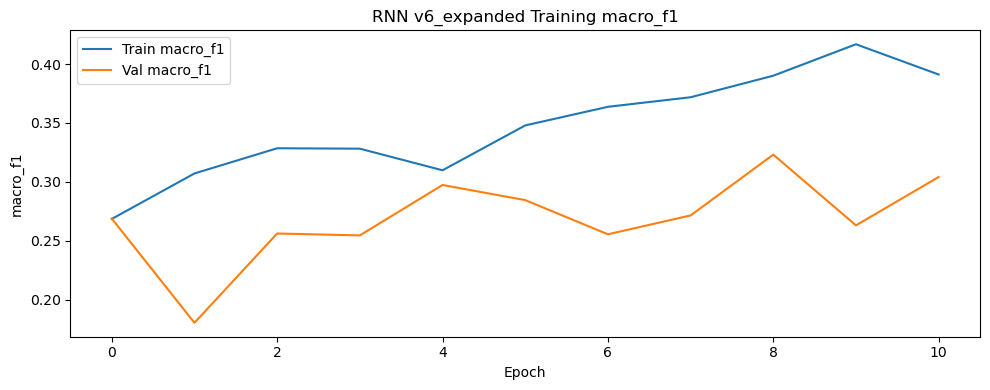

x_train_exp shape: (2774, 252, 51)
y_train_exp shape: (2774,)
x_val_exp shape: (594, 252, 51)
y_val_exp shape: (594,)
x_test_exp shape: (596, 252, 51)
y_test_exp shape: (596,)
Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 2.5591 - macro_f1: 0.2685 - val_loss: 2.2507 - val_macro_f1: 0.2688 - learning_rate: 7.0000e-04
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.5027 - macro_f1: 0.3071 - val_loss: 2.2725 - val_macro_f1: 0.1803 - learning_rate: 7.0000e-04
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4620 - macro_f1: 0.3285 - val_loss: 2.2427 - val_macro_f1: 0.2561 - learning_rate: 7.0000e-04
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4498 - macro_f1: 0.3282 - val_loss: 2.2854 - val_macro_f1: 0.2545 - learning_rate: 7.0000e-04
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.4594 - macro_f1: 0.3098 - val_loss: 2.2828 - val_macro_f1: 0.2973 - learning_rate: 7.0000e-04
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/ste

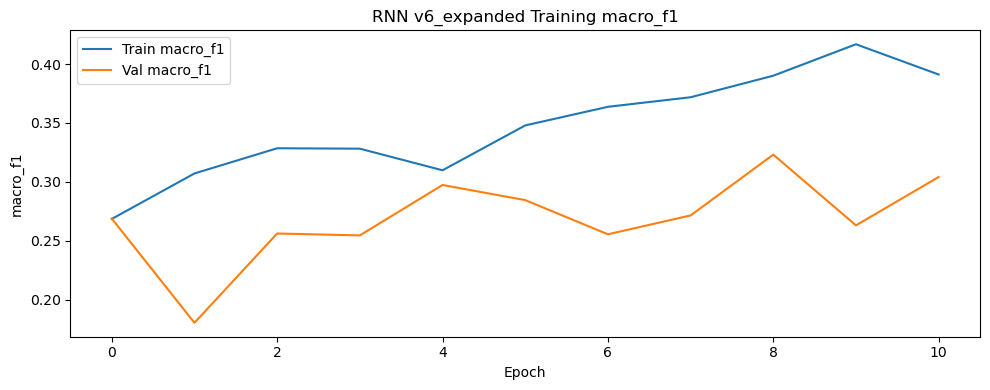

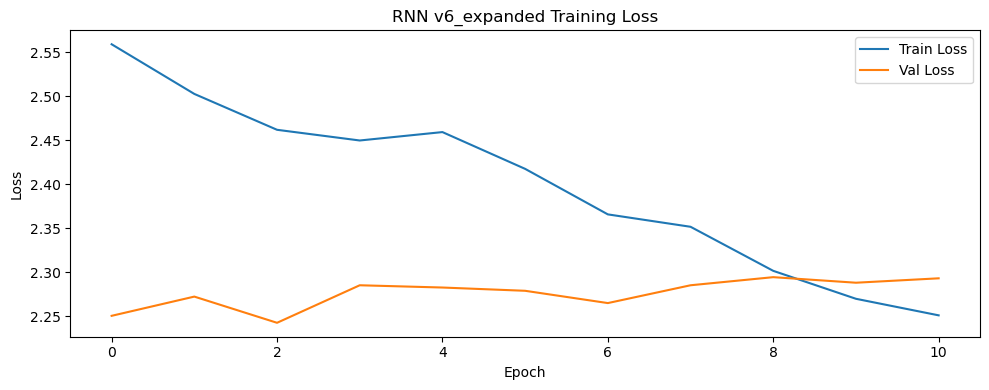

In [17]:
# Adding these seems meaningful information, let's see if it helps
x_train_exp, y_train_exp, x_val_exp, y_val_exp, x_test_exp, y_test_exp = single_stock_split(
    AAPL_data_expand,
    AAPLReturn,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=0,
    target_mode="direction_3class",
    return_index=False,
)

print("x_train_exp shape:", x_train_exp.shape)
print("y_train_exp shape:", y_train_exp.shape)
print("x_val_exp shape:", x_val_exp.shape)
print("y_val_exp shape:", y_val_exp.shape)
print("x_test_exp shape:", x_test_exp.shape)
print("y_test_exp shape:", y_test_exp.shape)

# v6: RNN on AAPL with expanded features (technical + SPY-related)

# labels are already in {0, 1, 2} from split
y_train_rnn_v6 = y_train_exp
y_val_rnn_v6 = y_val_exp
y_test_rnn_v6 = y_test_exp

# train-only normalization
train_mean_v6 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v6 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v6 = (x_train_exp - train_mean_v6) / train_std_v6
x_val_rnn_v6 = (x_val_exp - train_mean_v6) / train_std_v6
x_test_rnn_v6 = (x_test_exp - train_mean_v6) / train_std_v6

num_classes_v6 = 3
input_shape_v6 = x_train_rnn_v6.shape[1:]

keras.backend.clear_session()

rnn_model_v6 = keras.Sequential([
    layers.Input(shape=input_shape_v6),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v6, activation="softmax"),
])

# same cost-sensitive loss as before
loss_matrix_v6 = np.array([
    [0.0, 3.0, 3.0],  # true Down
    [0.0, 0.2, 0.0],  # true Flat
    [3.0, 3.0, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v6 = tf.constant(loss_matrix_v6, dtype=tf.float32)

def matrix_weighted_loss_v6(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v6)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v6)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v6 = 1.2
    return ce + lambda_cost_v6 * expected_cost

rnn_model_v6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v6,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v6)],
)

callbacks_v6 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v6 = rnn_model_v6.fit(
    x_train_rnn_v6,
    y_train_rnn_v6,
    validation_data=(x_val_rnn_v6, y_val_rnn_v6),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v6,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v6 = evaluate_keras_model_on_validation(
    model=rnn_model_v6,
    history=history_v6,
    x_val=x_val_rnn_v6,
    y_val_cat=y_val_rnn_v6,
    prefix="v6_expanded",
)


Just one more time treat everything in UP.
Still adding something let information richer


In [14]:
# Final market-feature pass: append only missing columns, then inspect what was added.
before_cols = set(AAPL_data_expand.columns)
AAPL_data_expand = add_more_market_feature(AAPL_data_expand, DATA_DIR / "SPY.csv")

added_cols = [c for c in AAPL_data_expand.columns if c not in before_cols and c.startswith(("spy_", "beta_", "alpha_", "aapl_excess_", "aapl_spy_"))]

print("New market-related columns:")
print(added_cols)

AAPL_data_expand[added_cols].head(20)

New market-related columns:
['spy_volatility_60', 'spy_volatility_ratio_20_60', 'spy_trend_5_20', 'spy_trend_20_50', 'beta_20', 'alpha_20', 'beta_252', 'alpha_252', 'beta_20_minus_252', 'alpha_20_minus_60', 'spy_shock_flag_q95_60', 'aapl_spy_sign_agree_20', 'aapl_spy_lag_corr_20', 'aapl_spy_sign_agree_60', 'aapl_spy_lag_corr_60', 'spy_volume_pressure_20', 'spy_volume_momentum_pressure_20', 'spy_bb_macd_pressure', 'aapl_spy_log_price_ratio', 'aapl_spy_log_price_ratio_ma_20', 'aapl_spy_log_price_ratio_slope_20', 'spy_market_state']


,spy_volatility_60,spy_volatility_ratio_20_60,spy_trend_5_20,spy_trend_20_50,beta_20,alpha_20,beta_252,alpha_252,beta_20_minus_252,alpha_20_minus_60,...,aapl_spy_lag_corr_20,aapl_spy_sign_agree_60,aapl_spy_lag_corr_60,spy_volume_pressure_20,spy_volume_momentum_pressure_20,spy_bb_macd_pressure,aapl_spy_log_price_ratio,aapl_spy_log_price_ratio_ma_20,aapl_spy_log_price_ratio_slope_20,spy_market_state
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.363263,NaN,NaN,1.0
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.411458,NaN,NaN,1.0
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.398721,NaN,NaN,1.0
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.473042,NaN,NaN,1.0
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.483193,NaN,NaN,1.0
2000-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.504368,NaN,NaN,1.0
2000-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.544844,NaN,NaN,1.0
2000-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.596672,NaN,NaN,1.0
2000-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-3.506075,NaN,NaN,1.0


x_train_exp shape: (2640, 252, 73)
y_train_exp shape: (2640,)
x_val_exp shape: (565, 252, 73)
y_val_exp shape: (565,)
x_test_exp shape: (567, 252, 73)
y_test_exp shape: (567,)
Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 2.5015 - macro_f1: 0.3014 - val_loss: 2.1822 - val_macro_f1: 0.3085 - learning_rate: 7.0000e-04
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 2.4526 - macro_f1: 0.3199 - val_loss: 2.1784 - val_macro_f1: 0.3218 - learning_rate: 7.0000e-04
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 2.4244 - macro_f1: 0.3303 - val_loss: 2.2147 - val_macro_f1: 0.3080 - learning_rate: 7.0000e-04
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 2.4087 - macro_f1: 0.3256 - val_loss: 2.1849 - val_macro_f1: 0.3639 - learning_rate: 7.0000e-04
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 2.3756 - macro_f1: 0.3558 - val_loss: 2.1760 - val_macro_f1: 0.3287 - learning_rate: 7.0000e-04
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/ste

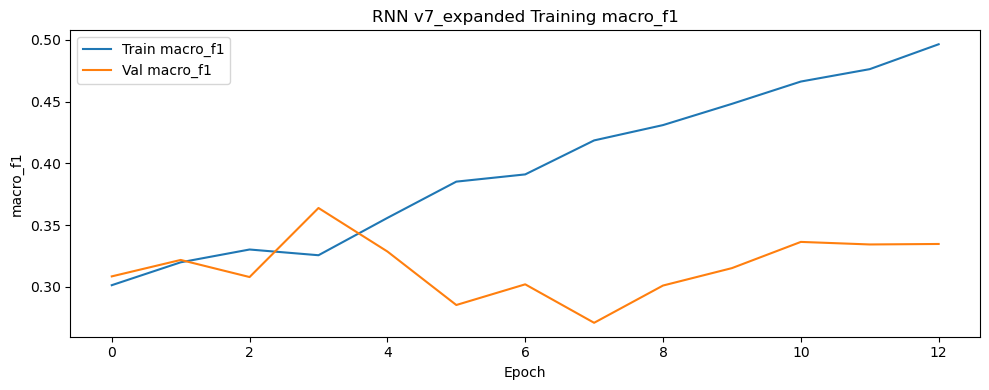

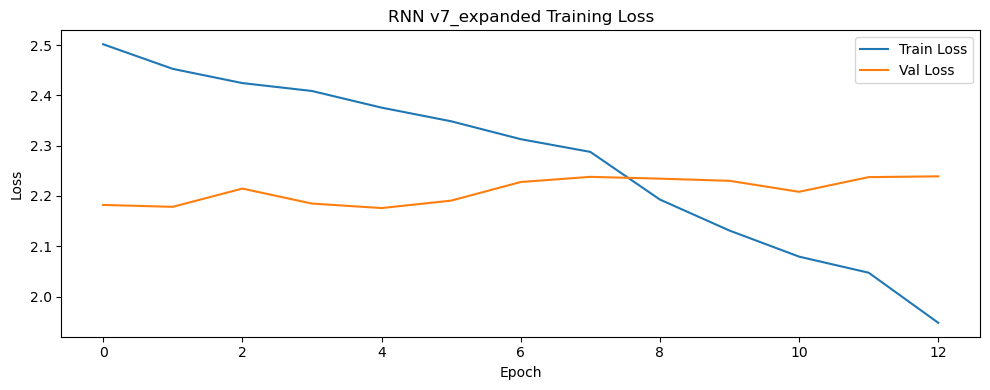

In [12]:
# After adding again, to see this time results
x_train_exp, y_train_exp, x_val_exp, y_val_exp, x_test_exp, y_test_exp = single_stock_split(
    AAPL_data_expand,
    AAPLReturn,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=0,
    target_mode="direction_3class",
    return_index=False,
)

print("x_train_exp shape:", x_train_exp.shape)
print("y_train_exp shape:", y_train_exp.shape)
print("x_val_exp shape:", x_val_exp.shape)
print("y_val_exp shape:", y_val_exp.shape)
print("x_test_exp shape:", x_test_exp.shape)
print("y_test_exp shape:", y_test_exp.shape)

# v7: RNN on AAPL with expanded features (technical + SPY-related)

# labels are already in {0, 1, 2} from split
y_train_rnn_v7 = y_train_exp
y_val_rnn_v7 = y_val_exp
y_test_rnn_v7 = y_test_exp

# train-only normalization
train_mean_v7 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v7 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v7 = (x_train_exp - train_mean_v7) / train_std_v7
x_val_rnn_v7 = (x_val_exp - train_mean_v7) / train_std_v7
x_test_rnn_v7 = (x_test_exp - train_mean_v7) / train_std_v7

num_classes_v7 = 3
input_shape_v7 = x_train_rnn_v7.shape[1:]

keras.backend.clear_session()

rnn_model_v7 = keras.Sequential([
    layers.Input(shape=input_shape_v7),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v7, activation="softmax"),
])

# same cost-sensitive loss as before
loss_matrix_v7 = np.array([
    [0.0, 3.0, 3.0],  # true Down
    [0.0, 0.0, 0.0],  # true Flat
    [3.0, 3.0, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v7 = tf.constant(loss_matrix_v7, dtype=tf.float32)

def matrix_weighted_loss_v7(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v7)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v7)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v7 = 1.2
    return ce + lambda_cost_v7 * expected_cost

rnn_model_v7.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v7,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v7)],
)

callbacks_v7 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v7 = rnn_model_v7.fit(
    x_train_rnn_v7,
    y_train_rnn_v7,
    validation_data=(x_val_rnn_v7, y_val_rnn_v7),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v7,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v7 = evaluate_keras_model_on_validation(
    model=rnn_model_v7,
    history=history_v7,
    x_val=x_val_rnn_v7,
    y_val_cat=y_val_rnn_v7,
    prefix="v7_expanded",
)


Intersting result. This time the model really try to learn, while the thing it learns is overfit

Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 2.5525 - macro_f1: 0.2306 - val_loss: 2.2333 - val_macro_f1: 0.2115 - learning_rate: 7.0000e-04
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.5102 - macro_f1: 0.1978 - val_loss: 2.2325 - val_macro_f1: 0.2359 - learning_rate: 7.0000e-04
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4812 - macro_f1: 0.2366 - val_loss: 2.2384 - val_macro_f1: 0.2736 - learning_rate: 7.0000e-04
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 2.4693 - macro_f1: 0.2618 - val_loss: 2.2366 - val_macro_f1: 0.2921 - learning_rate: 7.0000e-04
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4522 - macro_f1: 0.3202 - val_loss: 2.2389 - val_macro_f1: 0.2880 - learning_rate: 7.0000e-04
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 2.4328 - macro_f1: 0.3325 - val_loss: 2.2432 - val_macro_f1: 0.2875 - learning_rate: 3.5000e-04
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.4199 - ma

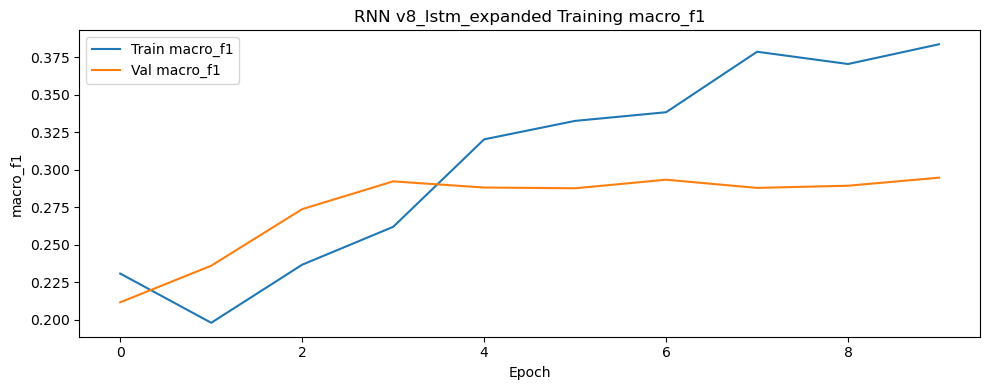

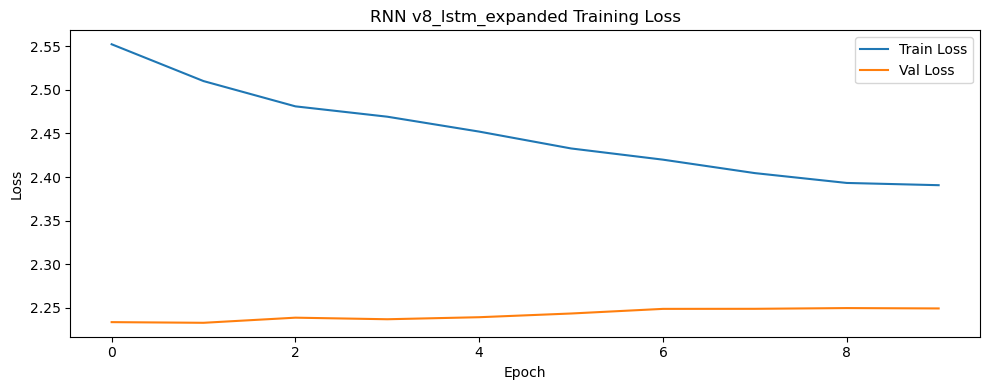

In [31]:
# change of model to try to solve the overfiting problem
# v8: LSTM on AAPL with expanded features (technical + SPY-related)


# labels are already in {0, 1, 2} from split
y_train_lstm_v8 = y_train_exp
y_val_lstm_v8 = y_val_exp
y_test_lstm_v8 = y_test_exp

# train-only normalization
train_mean_v8 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v8 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_lstm_v8 = (x_train_exp - train_mean_v8) / train_std_v8
x_val_lstm_v8 = (x_val_exp - train_mean_v8) / train_std_v8
x_test_lstm_v8 = (x_test_exp - train_mean_v8) / train_std_v8

num_classes_v8 = 3
input_shape_v8 = x_train_lstm_v8.shape[1:]

keras.backend.clear_session()

lstm_model_v8 = keras.Sequential([
    layers.Input(shape=input_shape_v8),
    layers.LSTM(32, activation="tanh", recurrent_activation="sigmoid", return_sequences=True),
    layers.Dropout(0.25),
    layers.LSTM(16, activation="tanh", recurrent_activation="sigmoid"),
    layers.Dropout(0.25),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes_v8, activation="softmax"),
])

# same cost-sensitive loss as v7
loss_matrix_v8 = np.array([
    [0.0, 3.0, 3.0],  # true Down
    [0.1, 0.0, 0.1],  # true Flat
    [3.0, 3.0, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v8 = tf.constant(loss_matrix_v8, dtype=tf.float32)

def matrix_weighted_loss_v8(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v8)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v8)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v8 = 1.2
    return ce + lambda_cost_v8 * expected_cost

lstm_model_v8.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v8,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v8)],
)

callbacks_v8 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v8 = lstm_model_v8.fit(
    x_train_lstm_v8,
    y_train_lstm_v8,
    validation_data=(x_val_lstm_v8, y_val_lstm_v8),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v8,
    verbose=1,
)

# direct validation evaluation helper
lstm_results_v8 = evaluate_keras_model_on_validation(
    model=lstm_model_v8,
    history=history_v8,
    x_val=x_val_lstm_v8,
    y_val_cat=y_val_lstm_v8,
    prefix="v8_lstm_expanded",
)




Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - loss: 2.2030 - macro_f1: 0.3451 - val_loss: 1.8485 - val_macro_f1: 0.2547 - learning_rate: 7.0000e-04
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - loss: 2.1667 - macro_f1: 0.3713 - val_loss: 1.8684 - val_macro_f1: 0.2664 - learning_rate: 7.0000e-04
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - loss: 2.1633 - macro_f1: 0.3857 - val_loss: 1.8720 - val_macro_f1: 0.2389 - learning_rate: 7.0000e-04
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - loss: 2.1422 - macro_f1: 0.3931 - val_loss: 1.8714 - val_macro_f1: 0.2333 - learning_rate: 7.0000e-04
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - loss: 2.1188 - macro_f1: 0.4077 - val_loss: 1.8595 - val_macro_f1: 0.2618 - learning_rate: 3.5000e-04
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - loss: 2.1179 - macro_f1: 0.4340 - val_loss: 1.8544 - val_macro_f1: 0.2720 - learning_rate: 3.5000e-04
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - los

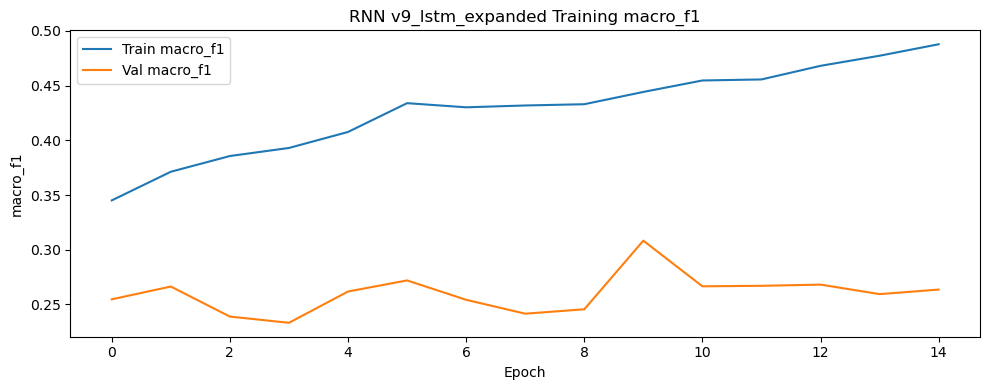

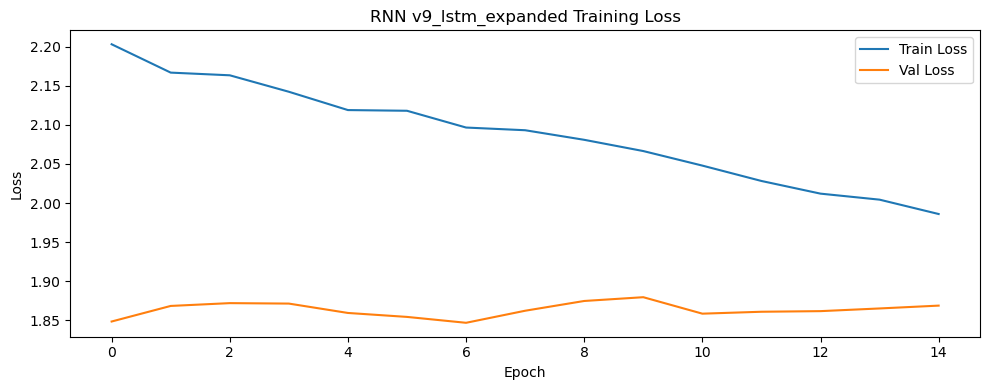

In [33]:
# change of model to try to solve the overfiting problem
# v9: LSTM on AAPL with expanded features (technical + SPY-related)
# more complicated LSTM


# labels are already in {0, 1, 2} from split
y_train_lstm_v9 = y_train_exp
y_val_lstm_v9 = y_val_exp
y_test_lstm_v9 = y_test_exp

# train-only normalization
train_mean_v9 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v9 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_lstm_v9 = (x_train_exp - train_mean_v9) / train_std_v9
x_val_lstm_v9 = (x_val_exp - train_mean_v9) / train_std_v9
x_test_lstm_v9 = (x_test_exp - train_mean_v9) / train_std_v9

num_classes_v9 = 3
input_shape_v9 = x_train_lstm_v9.shape[1:]

keras.backend.clear_session()

lstm_model_v9 = keras.Sequential([
    layers.Input(shape=input_shape_v9),
    layers.LSTM(128, activation="tanh", recurrent_activation="sigmoid", return_sequences=True),
    layers.Dropout(0.4),
    layers.LSTM(64, activation="tanh", recurrent_activation="sigmoid"),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v9, activation="softmax"),
])

# same cost-sensitive loss as v7
loss_matrix_v9 = np.array([
    [0.0, 1.5, 3.0],  # true Down
    [0.1, 0.0, 0.1],  # true Flat
    [3.0, 1.5, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v9 = tf.constant(loss_matrix_v9, dtype=tf.float32)

def matrix_weighted_loss_v9(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v9)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v9)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v9 = 1.2
    return ce + lambda_cost_v9 * expected_cost

lstm_model_v9.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v9,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v9)],
)

callbacks_v9 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v9 = lstm_model_v9.fit(
    x_train_lstm_v9,
    y_train_lstm_v9,
    validation_data=(x_val_lstm_v9, y_val_lstm_v9),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v9,
    verbose=1,
)

# direct validation evaluation helper
lstm_results_v9 = evaluate_keras_model_on_validation(
    model=lstm_model_v9,
    history=history_v9,
    x_val=x_val_lstm_v9,
    y_val_cat=y_val_lstm_v9,
    prefix="v9_lstm_expanded",
)




Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 39s 438ms/step - loss: 2.1966 - macro_f1: 0.3761 - val_loss: 1.8534 - val_macro_f1: 0.2347 - learning_rate: 7.0000e-04
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 437ms/step - loss: 2.1797 - macro_f1: 0.3429 - val_loss: 1.8527 - val_macro_f1: 0.2347 - learning_rate: 7.0000e-04
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 433ms/step - loss: 2.1805 - macro_f1: 0.3384 - val_loss: 1.8483 - val_macro_f1: 0.2347 - learning_rate: 7.0000e-04
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 433ms/step - loss: 2.1790 - macro_f1: 0.3867 - val_loss: 1.8478 - val_macro_f1: 0.2347 - learning_rate: 7.0000e-04
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 453ms/step - loss: 2.1767 - macro_f1: 0.3572 - val_loss: 1.8543 - val_macro_f1: 0.2347 - learning_rate: 7.0000e-04
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 444ms/step - loss: 2.1710 - macro_f1: 0.3555 - val_loss: 1.8535 - val_macro_f1: 0.2347 - learning_rate: 7.0000e-04
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 37s 451ms/step - los

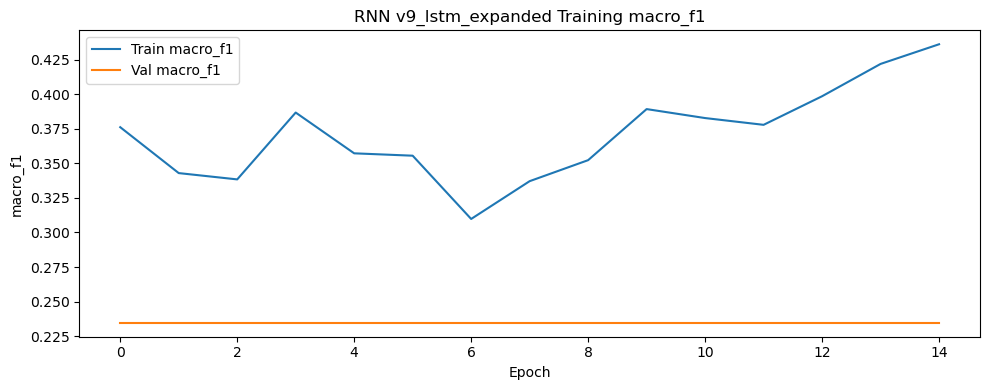

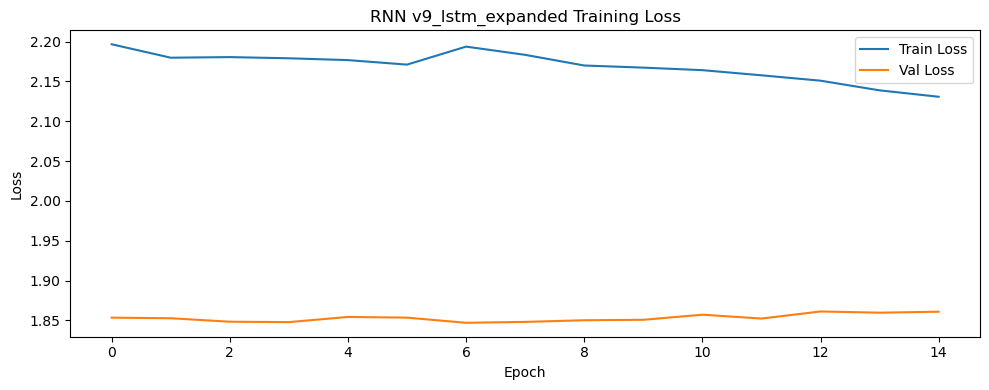

In [14]:
# is adding more complexity of model just to make it more concentrate on some single forcasting label?
# v10: LSTM on AAPL with expanded features (technical + SPY-related)
# more complicated LSTM + more cost on flat prediction

# labels are already in {0, 1, 2} from split
y_train_lstm_v9 = y_train_exp
y_val_lstm_v9 = y_val_exp
y_test_lstm_v9 = y_test_exp

# train-only normalization
train_mean_v9 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v9 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_lstm_v9 = (x_train_exp - train_mean_v9) / train_std_v9
x_val_lstm_v9 = (x_val_exp - train_mean_v9) / train_std_v9
x_test_lstm_v9 = (x_test_exp - train_mean_v9) / train_std_v9

num_classes_v9 = 3
input_shape_v9 = x_train_lstm_v9.shape[1:]

keras.backend.clear_session()

lstm_model_v9 = keras.Sequential([
    layers.Input(shape=input_shape_v9),
    layers.LSTM(256, activation="tanh", recurrent_activation="sigmoid", return_sequences=True),
    layers.Dropout(0.4),
    layers.LSTM(256, activation="tanh", recurrent_activation="sigmoid", return_sequences=True),
    layers.Dropout(0.4),
    layers.LSTM(64, activation="tanh", recurrent_activation="sigmoid", return_sequences=False),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v9, activation="softmax"),
])

# same cost-sensitive loss as v7
loss_matrix_v9 = np.array([
    [0.0, 1.5, 3.0],  # true Down
    [0.1, 0.0, 0.1],  # true Flat
    [3.0, 1.5, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v9 = tf.constant(loss_matrix_v9, dtype=tf.float32)

def matrix_weighted_loss_v9(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v9)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v9)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v9 = 1.2
    return ce + lambda_cost_v9 * expected_cost

lstm_model_v9.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v9,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v9)],
)

callbacks_v9 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v9 = lstm_model_v9.fit(
    x_train_lstm_v9,
    y_train_lstm_v9,
    validation_data=(x_val_lstm_v9, y_val_lstm_v9),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v9,
    verbose=1,
)

# direct validation evaluation helper
lstm_results_v9 = evaluate_keras_model_on_validation(
    model=lstm_model_v9,
    history=history_v9,
    x_val=x_val_lstm_v9,
    y_val_cat=y_val_lstm_v9,
    prefix="v9_lstm_expanded",
)



**The result just confirmed the previous idea: with the model be more complex, the prediction it makes tend to concentrate in one category.**

### Problems right now:
* The data size right now is still too small for a complex model(over parameterization)
* The signal is just too weak

### Other direction we can still try to struggle
* The small of the data itself. 1. adding through putting the rest other data inside 2. using interaction term to adding the feature volalitily, and hoping for the magic to come


In [15]:
# adding more stock features, after considering the self-feature of other stocks and the correled features
AAPL_data_expand, other_features_big_table, other_feature_audit = expand_with_other_stock_features(
    base_features_df=AAPL_data_expand,
    data_dir=DATA_DIR,
    exclude_stocks={"AAPL", "MA", "V", "FB", "XLRE"},
    add_stock_technical_features=True,
    add_cross_asset_features=True,
    drop_high_nan_features=True,   # drop columns with more than 40% NaN after merging, to avoid too much imputation noise
    nan_drop_threshold=0.40,       
    other_join="inner",
    final_join="left",
)

print("Cross-asset columns added:", len(other_feature_audit["cross_asset_added_columns"]))
print("Dropped high-NaN columns:", len(other_feature_audit["dropped_high_nan_columns"]))
print(other_feature_audit)

Cross-asset columns added: 101
Dropped high-NaN columns: 0
{'used_tickers': ['ACN', 'ADBE', 'CRM', 'CSCO', 'GOOG', 'IBM', 'INTC', 'MSFT', 'NVDA', 'SPY', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY'], 'other_features_shape': (4277, 551), 'base_shape': (4277, 73), 'expanded_shape': (4277, 725), 'other_date_min': Timestamp('2000-01-03 00:00:00'), 'other_date_max': Timestamp('2016-12-30 00:00:00'), 'duplicated_columns': [], 'cross_asset_added_columns': ['peer_breadth_up', 'peer_dispersion', 'aapl_minus_xlk_ret_1d', 'aapl_minus_msft_ret_1d', 'aapl_minus_spy_ret_1d', 'aapl_xlk_log_price_ratio', 'aapl_xlk_spread_mom_5', 'aapl_xlk_spread_mom_20', 'aapl_msft_log_price_ratio', 'aapl_msft_spread_mom_5', 'aapl_msft_spread_mom_20', 'aapl_spy_spread_mom_5', 'aapl_spy_spread_mom_20', 'corr20_aapl_xlk', 'corr60_aapl_xlk', 'corr20_aapl_msft', 'corr60_aapl_msft', 'corr20_aapl_spy', 'corr60_aapl_spy', 'xlk_rel_spy_ret_1d', 'xlk_rel_spy_ret_5', 'xlk_rotation_speed_5', 'xly_rel_spy_ret_1d'

/Users/tianmushang/Desktop/the study in class/FRE 7773/ML_Spring_2026/assignments/stock_prediction/tools.py:473: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = series


In [ ]:
# check after adding, how data looks like
AAPL_data_expand.shape

(4277, 725)

Epoch 1/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 2.2543 - macro_f1: 0.2982 - val_loss: 1.9060 - val_macro_f1: 0.2418 - learning_rate: 7.0000e-04
Epoch 2/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 2.2385 - macro_f1: 0.3053 - val_loss: 1.9429 - val_macro_f1: 0.2919 - learning_rate: 7.0000e-04
Epoch 3/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 2.2074 - macro_f1: 0.3447 - val_loss: 1.9846 - val_macro_f1: 0.2791 - learning_rate: 7.0000e-04
Epoch 4/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 2.1900 - macro_f1: 0.3897 - val_loss: 1.9213 - val_macro_f1: 0.3113 - learning_rate: 7.0000e-04
Epoch 5/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 2.1610 - macro_f1: 0.4007 - val_loss: 1.9524 - val_macro_f1: 0.2911 - learning_rate: 3.5000e-04
Epoch 6/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 2.1447 - macro_f1: 0.4111 - val_loss: 1.9264 - val_macro_f1: 0.2809 - learning_rate: 3.5000e-04
Epoch 7/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 2.1180 - ma

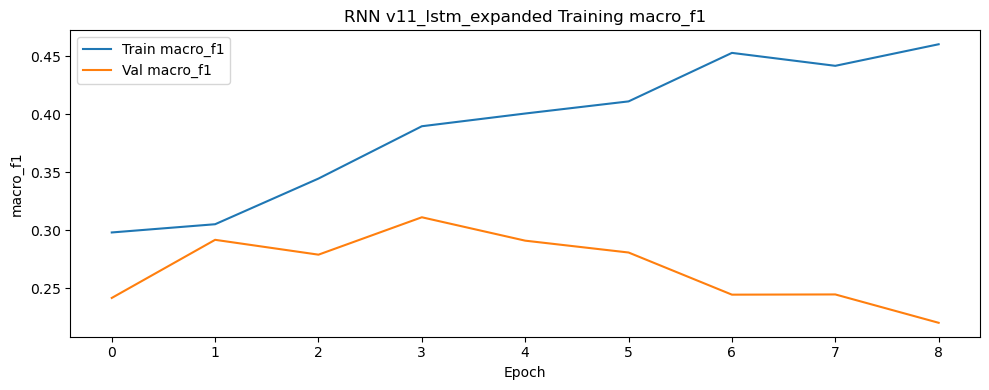

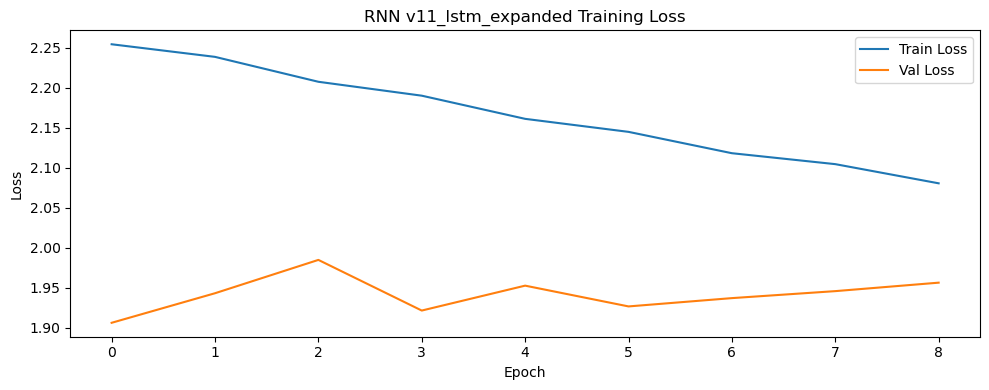

In [17]:
# use this to do the LSTM once more (relatively simple LSTM structure, to see if the new features can help)

# v11: LSTM on AAPL with expanded features + other stock features (technical + SPY-related + cross-asset)
# labels are already in {0, 1, 2} from split
x_train_exp, y_train_exp, x_val_exp, y_val_exp, x_test_exp, y_test_exp = single_stock_split(
    AAPL_data_expand,
    AAPLReturn,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    window_size=252,
    add_transformed_features=0,
    target_mode="direction_3class",
    return_index=False,
)


# labels are already in {0, 1, 2} from split
y_train_lstm_v11 = y_train_exp
y_val_lstm_v11 = y_val_exp
y_test_lstm_v11 = y_test_exp

# train-only normalization
train_mean_v11 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v11 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_lstm_v11 = (x_train_exp - train_mean_v11) / train_std_v11
x_val_lstm_v11 = (x_val_exp - train_mean_v11) / train_std_v11
x_test_lstm_v11 = (x_test_exp - train_mean_v11) / train_std_v11

num_classes_v11 = 3
input_shape_v11 = x_train_lstm_v11.shape[1:]

keras.backend.clear_session()

lstm_model_v11 = keras.Sequential([
    layers.Input(shape=input_shape_v11),
    layers.LSTM(32, activation="tanh", recurrent_activation="sigmoid", return_sequences=True),
    layers.Dropout(0.25),
    layers.LSTM(16, activation="tanh", recurrent_activation="sigmoid"),
    layers.Dropout(0.25),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes_v11, activation="softmax"),
])

# same cost-sensitive loss as v7
loss_matrix_v11 = np.array([
    [0.0, 2.0, 3.0],  # true Down
    [0.1, 0.0, 0.1],  # true Flat
    [3.0, 2.0, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v11 = tf.constant(loss_matrix_v11, dtype=tf.float32)

def matrix_weighted_loss_v11(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v11)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v11)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v11 = 1.2
    return ce + lambda_cost_v11 * expected_cost

lstm_model_v11.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v11,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v11)],
)

callbacks_v11 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v11 = lstm_model_v11.fit(
    x_train_lstm_v11,
    y_train_lstm_v11,
    validation_data=(x_val_lstm_v11, y_val_lstm_v11),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v11,
    verbose=1,
)

# direct validation evaluation helper
lstm_results_v11 = evaluate_keras_model_on_validation(
    model=lstm_model_v11,
    history=history_v11,
    x_val=x_val_lstm_v11,
    y_val_cat=y_val_lstm_v11,
    prefix="v11_lstm_expanded",
)




Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 1.1858 - macro_f1: 0.3423 - val_loss: 1.1334 - val_macro_f1: 0.1620 - learning_rate: 1.0000e-04
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 1.1350 - macro_f1: 0.3666 - val_loss: 1.0979 - val_macro_f1: 0.2558 - learning_rate: 1.0000e-04
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 1.1258 - macro_f1: 0.3728 - val_loss: 1.0587 - val_macro_f1: 0.2970 - learning_rate: 1.0000e-04
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 1.1108 - macro_f1: 0.3773 - val_loss: 1.0613 - val_macro_f1: 0.3357 - learning_rate: 1.0000e-04
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 1.0995 - macro_f1: 0.3907 - val_loss: 1.0706 - val_macro_f1: 0.2785 - learning_rate: 1.0000e-04
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 1.0829 - macro_f1: 0.3874 - val_loss: 1.0543 - val_macro_f1: 0.2854 - learning_rate: 1.0000e-04
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/ste

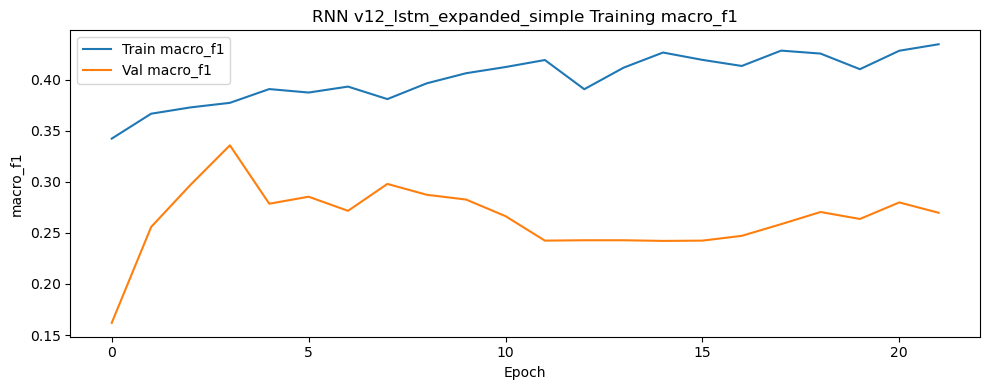

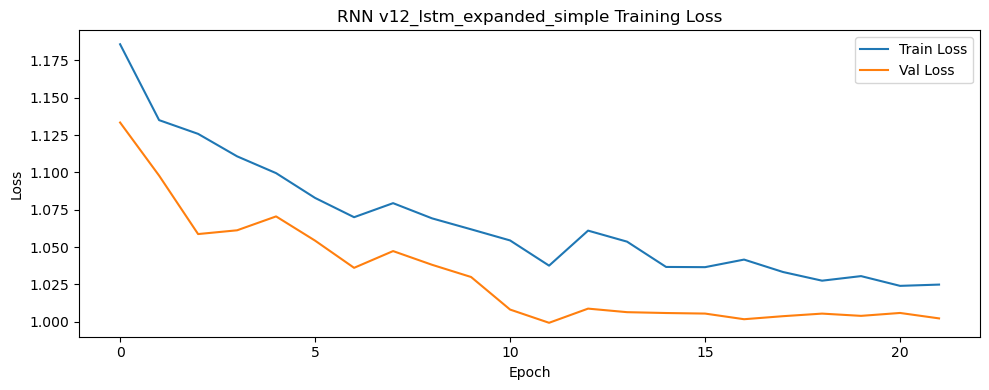

In [22]:
# It may learn something at begining, but then just get into flat again
# simply the model

# labels are already in {0, 1, 2} from split
y_train_lstm_v12 = y_train_exp
y_val_lstm_v12 = y_val_exp
y_test_lstm_v12 = y_test_exp

# train-only normalization
train_mean_v12 = x_train_exp.mean(axis=(0, 1), keepdims=True)
train_std_v12 = x_train_exp.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_lstm_v12 = (x_train_exp - train_mean_v12) / train_std_v12
x_val_lstm_v12 = (x_val_exp - train_mean_v12) / train_std_v12
x_test_lstm_v12 = (x_test_exp - train_mean_v12) / train_std_v12

num_classes_v12 = 3
input_shape_v12 = x_train_lstm_v12.shape[1:]

keras.backend.clear_session()


lstm_model_v12 = keras.Sequential([
    layers.Input(shape=input_shape_v12),
    layers.LSTM(32, activation="tanh", recurrent_activation="sigmoid"),
    layers.Dropout(0.75),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes_v12, activation="softmax"),
])

lstm_model_v12.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v12)],
)
callbacks_v12 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]
history_v12 = lstm_model_v12.fit(
    x_train_lstm_v12,
    y_train_lstm_v12,
    validation_data=(x_val_lstm_v12, y_val_lstm_v12),
    epochs=100,
    batch_size=16,
    callbacks=callbacks_v12,
    verbose=1,
)
# direct validation evaluation helper
lstm_results_v12 = evaluate_keras_model_on_validation(
    model=lstm_model_v12,
    history=history_v12,
    x_val=x_val_lstm_v12,
    y_val_cat=y_val_lstm_v12,
    prefix="v12_lstm_expanded_simple",
)


In [ ]:
# I Mean, some trial: adding the interaction feature on everything
AAPL_data_expand_interact = add_interaction_features(AAPL_data_expand, interaction_degree=2)
print("After interaction, shape:", AAPL_data_expand_interact.shape)

NameError: name 'add_interaction_features' is not defined